<h1 style='text-align: center'>🏡 EDA - House Prices - Advanced Regression Techniques 🏘</h1>

<p  style='text-align: center'>
This notebook is in <span style='color: green; font-weight: 700'>Active</span> state of development! Check out this notebook to see some updates as I update new stuff as oftern as I learn it!
<a style='font-weight:700' href='https://github.com/LilDataScientist'> Code on GitHub! </a></p>

<div style='text-align: center'>
    <img src='https://i.postimg.cc/Y0FYKBqY/house.jpg' width='600' />
</div>

In [1]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import h2o

from h2o.automl import H2OAutoML

sns.set_theme()
sns.set_palette('muted')

h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321 ..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "11.0.11" 2021-04-20; OpenJDK Runtime Environment (build 11.0.11+9-Ubuntu-0ubuntu2.18.04); OpenJDK 64-Bit Server VM (build 11.0.11+9-Ubuntu-0ubuntu2.18.04, mixed mode, sharing)
  Starting server from /opt/conda/lib/python3.7/site-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmpvulxda7m
  JVM stdout: /tmp/tmpvulxda7m/h2o_unknownUser_started_from_python.out
  JVM stderr: /tmp/tmpvulxda7m/h2o_unknownUser_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,02 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.34.0.1
H2O_cluster_version_age:,25 days
H2O_cluster_name:,H2O_from_python_unknownUser_21pkd0
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,4 Gb
H2O_cluster_total_cores:,4
H2O_cluster_allowed_cores:,4
H2O_cluster_status:,"locked, healthy"


In [2]:
df = pd.read_csv('../input/house-prices-advanced-regression-techniques/train.csv')

df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [3]:
def categorial_feature_overview(feature, rotation=0):
    print(feature, 'has', df[feature].isnull().sum() / len(df) * 100, '% of null values')
    f,ax = plt.subplots(1, 2, figsize=(20, 6))
    ax[0].tick_params(labelrotation=rotation)
    ax[1].tick_params(labelrotation=rotation)
    sns.countplot(data=df, x=feature, ax=ax[0]);
    sns.boxplot(data=df, x=feature, y='SalePrice', ax=ax[1])
    plt.show()
    
def numerical_feature_overview(feature, rotation=0):
    print(feature, 'has', df[feature].isnull().sum() / len(df) * 100, '% of null values')
    f,ax = plt.subplots(1, 2, figsize=(20, 6))
    ax[0].tick_params(labelrotation=rotation)
    ax[1].tick_params(labelrotation=rotation)
    sns.scatterplot(data=df, x=feature, y='SalePrice', ax=ax[0]);
    sns.boxplot(data=df, x=feature, ax=ax[1])
    plt.show()

# MSSubClass

Identifies the type of dwelling involved in the sale.

* 20 - 1-STORY 1946 & NEWER ALL STYLES
* 30 - 1-STORY 1945 & OLDER
* 40 - 1-STORY W/FINISHED ATTIC ALL AGES
* 45 - 1-1/2 STORY - UNFINISHED ALL AGES
* 50 - 1-1/2 STORY FINISHED ALL AGES
* 60 - 2-STORY 1946 & NEWER
* 70 - 2-STORY 1945 & OLDER
* 75 - 2-1/2 STORY ALL AGES
* 80 - SPLIT OR MULTI-LEVEL
* 85 - SPLIT FOYER
* 90 - DUPLEX - ALL STYLES AND AGES
* 120 - 1-STORY PUD (Planned Unit Development) - 1946 & NEWER
* 150 - 1-1/2 STORY PUD - ALL AGES
* 160 - 2-STORY PUD - 1946 & NEWER
* 180 - PUD - MULTILEVEL - INCL SPLIT LEV/FOYER
* 190 - 2 FAMILY CONVERSION - ALL STYLES AND AGES

MSSubClass has 0.0 % of null values


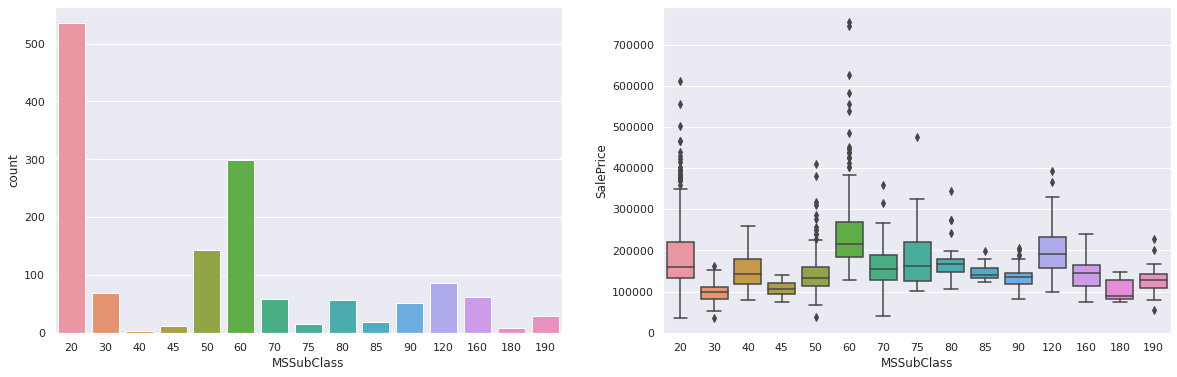

In [4]:
categorial_feature_overview('MSSubClass')

# MSZoning

Identifies the general zoning classification of the sale.

* A - Agriculture
* C - Commercial
* FV - Floating Village Residential
* I - Industrial
* RH - Residential High Density
* RL - Residential Low Density
* RP - Residential Low Density Park 
* RM - Residential Medium Density

MSZoning has 0.0 % of null values


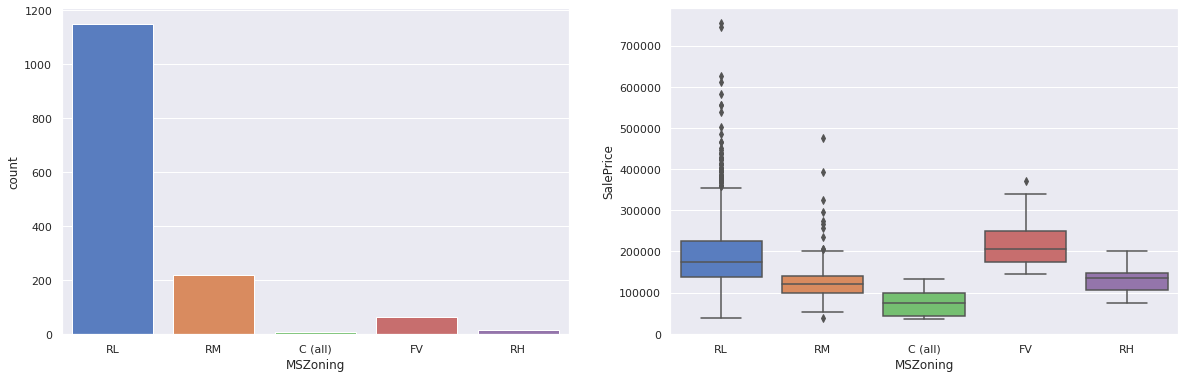

In [5]:
categorial_feature_overview('MSZoning')

# LotFrontage

Linear feet of street connected to property

LotFrontage has 17.73972602739726 % of null values


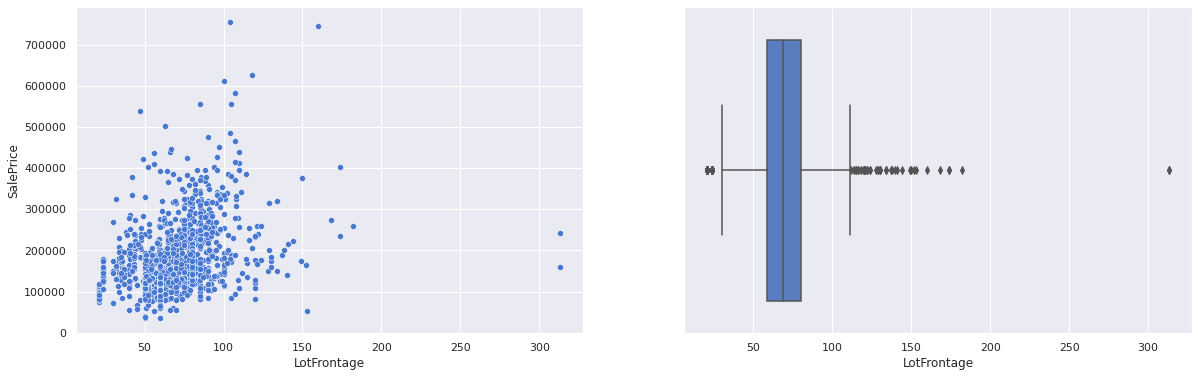

In [6]:
numerical_feature_overview('LotFrontage')

# LotArea

Lot size in square feet

LotArea has 0.0 % of null values


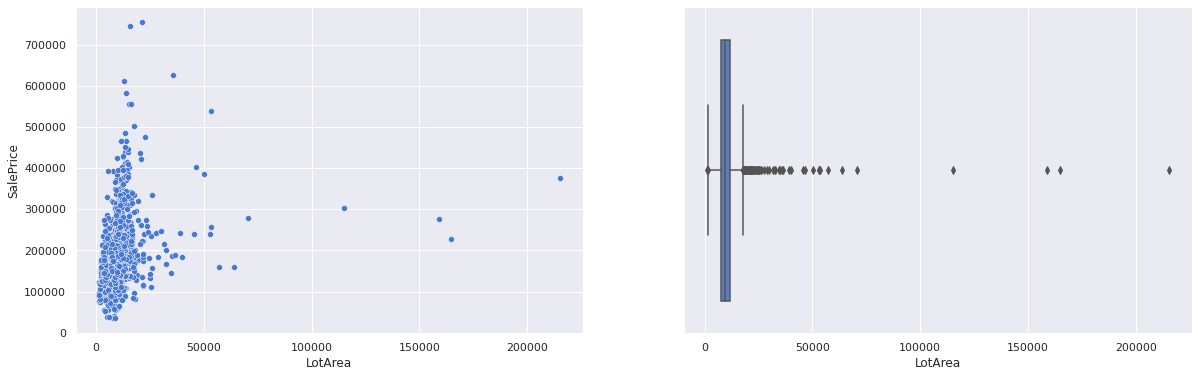

In [7]:
numerical_feature_overview('LotArea')

# Street

Type of road access to property

* Grvl - Gravel
* Pave - Paved

Street has 0.0 % of null values


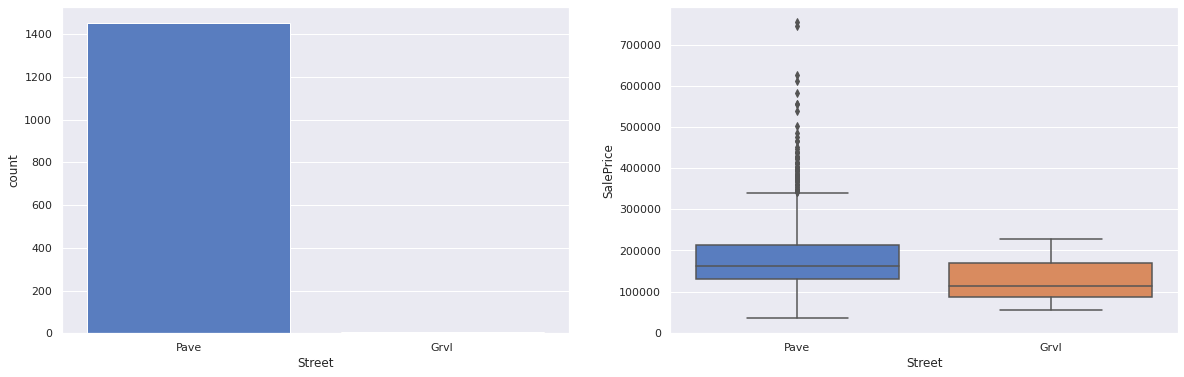

In [8]:
categorial_feature_overview('Street')

# Alley

Type of alley access to property

* Grvl - Gravel
* Pave - Paved
* NA - No alley access

Alley has 93.76712328767123 % of null values


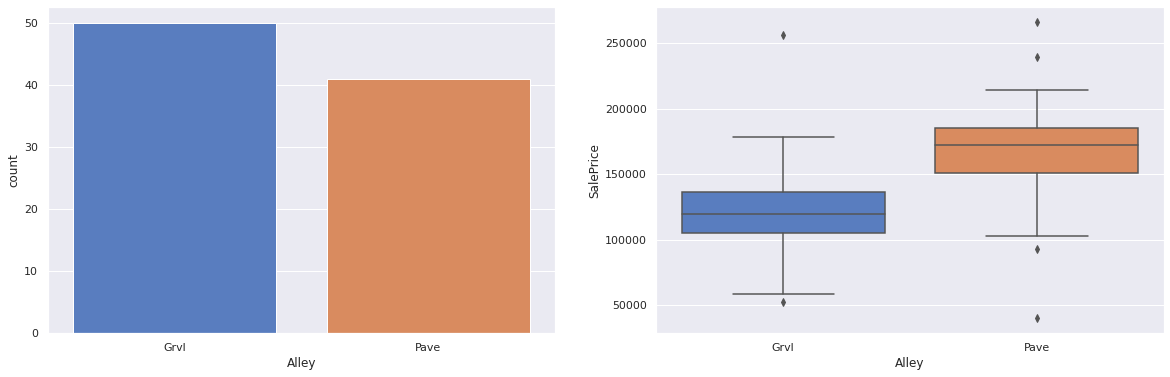

In [9]:
categorial_feature_overview('Alley')

# LotShape

General shape of property

* Reg - Regular
* IR1 - Slightly irregular
* IR2 - Moderately Irregular
* IR3 - Irregular

LotShape has 0.0 % of null values


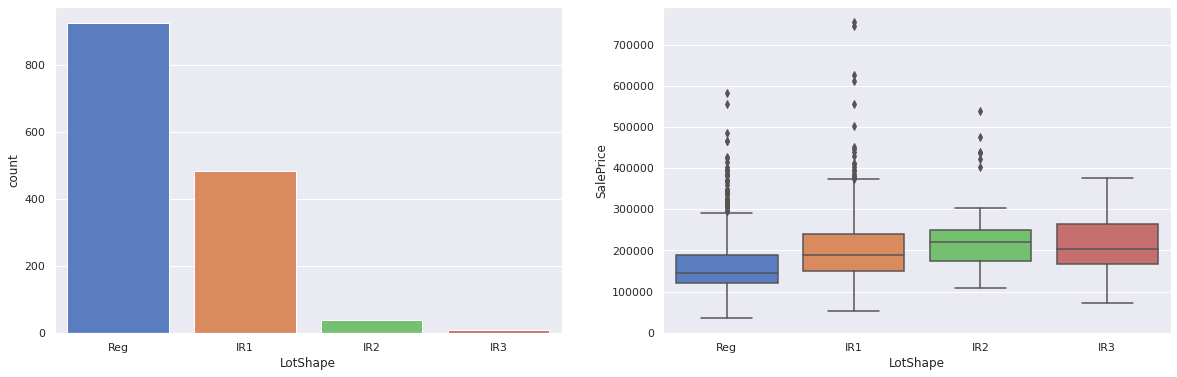

In [10]:
categorial_feature_overview('LotShape')

# LandContour

Flatness of the property

* Lvl - Near Flat/Level
* Bnk - Banked - Quick and significant rise from street grade to building
* HLS - Hillside - Significant slope from side to side
* Low - Depression

LandContour has 0.0 % of null values


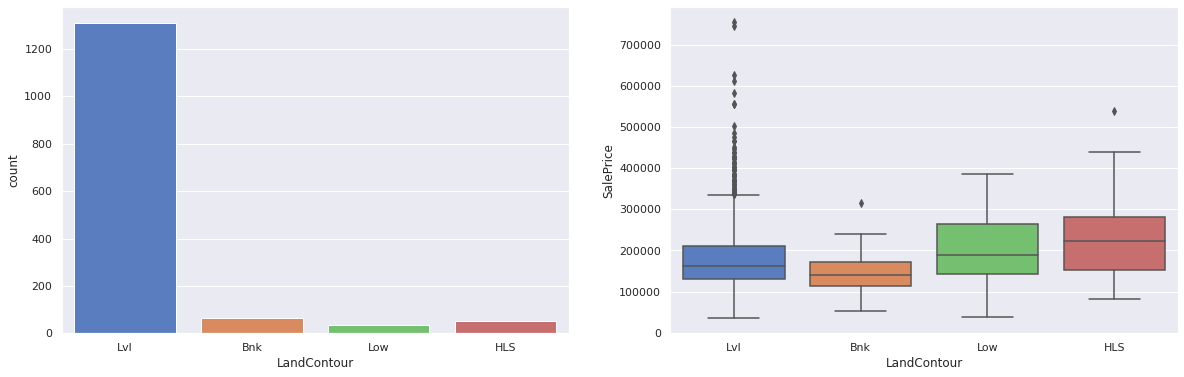

In [11]:
categorial_feature_overview('LandContour')

# Utilities

Type of utilities available

* AllPub - All public Utilities (E,G,W,& S)
* NoSewr - Electricity, Gas, and Water (Septic Tank)
* NoSeWa - Electricity and Gas Only
* ELO - Electricity only

Utilities has 0.0 % of null values


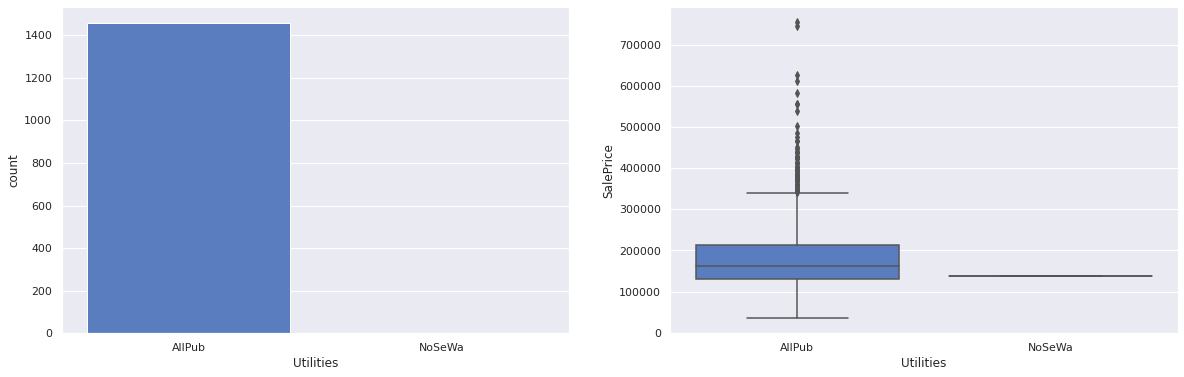

In [12]:
categorial_feature_overview('Utilities')

# LotConfig

Lot configuration

* Inside - Inside lot
* Corner - Corner lot
* CulDSac - Cul-de-sac
* FR2 - Frontage on 2 sides of property
* FR3 - Frontage on 3 sides of property

LotConfig has 0.0 % of null values


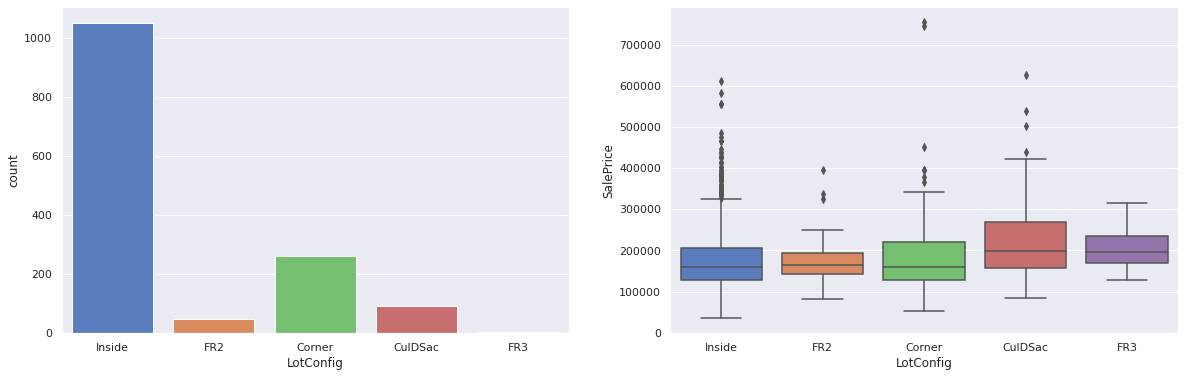

In [13]:
categorial_feature_overview('LotConfig')

# LandSlope

#### Slope of property

* Gtl Gentle slope
* Mod Moderate Slope
* Sev Severe Slope

LandSlope has 0.0 % of null values


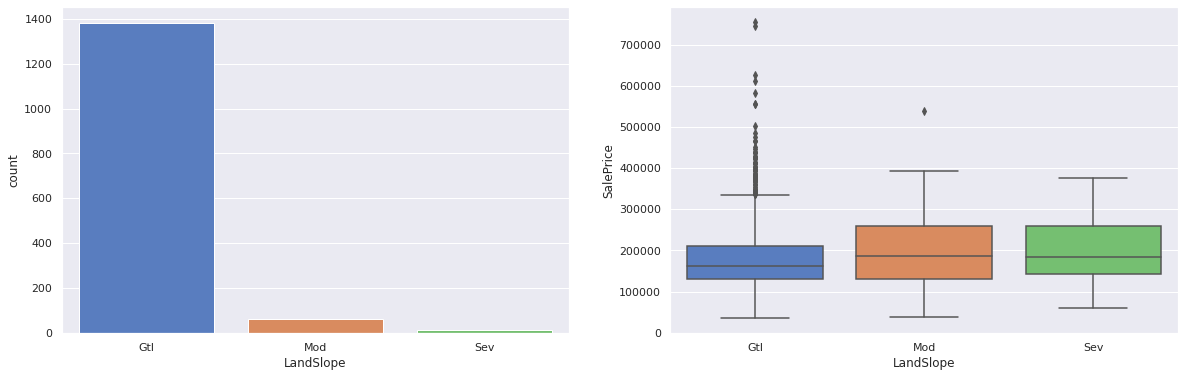

In [14]:
categorial_feature_overview('LandSlope')

# Neighborhood

Physical locations within Ames city limits

* Blmngtn - Bloomington Heights
* Blueste - Bluestem
* BrDale - Briardale
* BrkSide - Brookside
* ClearCr - Clear Creek
* CollgCr - College Creek
* Crawfor - Crawford
* Edwards - Edwards
* Gilbert - Gilbert
* IDOTRR - Iowa DOT and Rail Road
* MeadowV - Meadow Village
* Mitchel - Mitchell
* Names - North Ames
* NoRidge - Northridge
* NPkVill - Northpark Villa
* NridgHt - Northridge Heights
* NWAmes - Northwest Ames
* OldTown - Old Town
* SWISU - South & West of Iowa State University
* Sawyer - Sawyer
* SawyerW - Sawyer West
* Somerst - Somerset
* StoneBr - Stone Brook
* Timber - Timberland
* Veenker - Veenker

Neighborhood has 0.0 % of null values


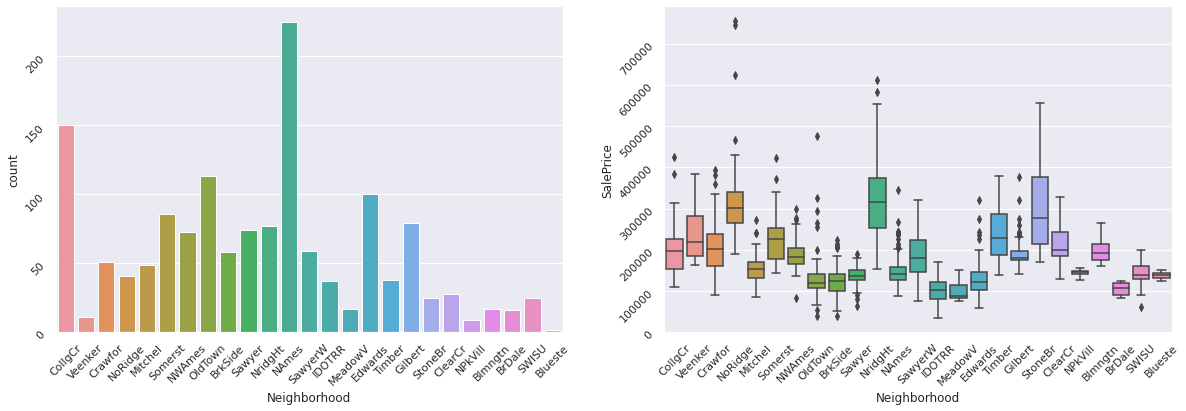

In [15]:
categorial_feature_overview('Neighborhood', rotation=45)

# Condition1

Proximity to various conditions

* Artery - Adjacent to arterial street
* Feedr - Adjacent to feeder street
* Norm - Normal
* RRNn - Within 200' of North-South Railroad
* RRAn - Adjacent to North-South Railroad
* PosN - Near positive off-site feature--park, greenbelt, etc.
* PosA - Adjacent to postive off-site feature
* RRNe - Within 200' of East-West Railroad
* RRAe - Adjacent to East-West Railroad

Condition1 has 0.0 % of null values


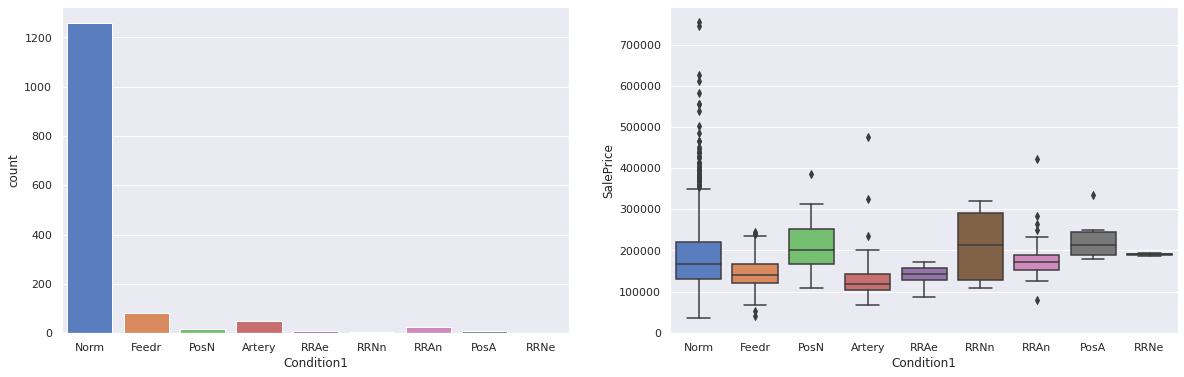

In [16]:
categorial_feature_overview('Condition1')

# Condition2

Proximity to various conditions (if more than one is present)

* Artery - Adjacent to arterial street
* Feedr - Adjacent to feeder street
* Norm - Normal
* RRNn - Within 200' of North-South Railroad
* RRAn - Adjacent to North-South Railroad
* PosN - Near positive off-site feature--park, greenbelt, etc.
* PosA - Adjacent to postive off-site feature
* RRNe - Within 200' of East-West Railroad
* RRAe - Adjacent to East-West Railroad

Condition2 has 0.0 % of null values


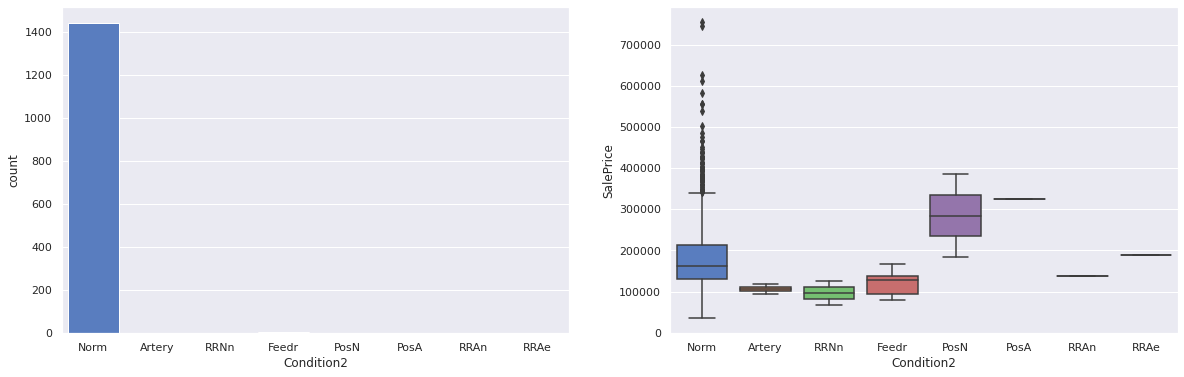

In [17]:
categorial_feature_overview('Condition2')

# RoofStyle

Type of roof

* Flat - Flat
* Gable - Gable
* Gambrel - Gabrel (Barn)
* Hip - Hip
* Mansard - Mansard
* Shed - Shed

RoofStyle has 0.0 % of null values


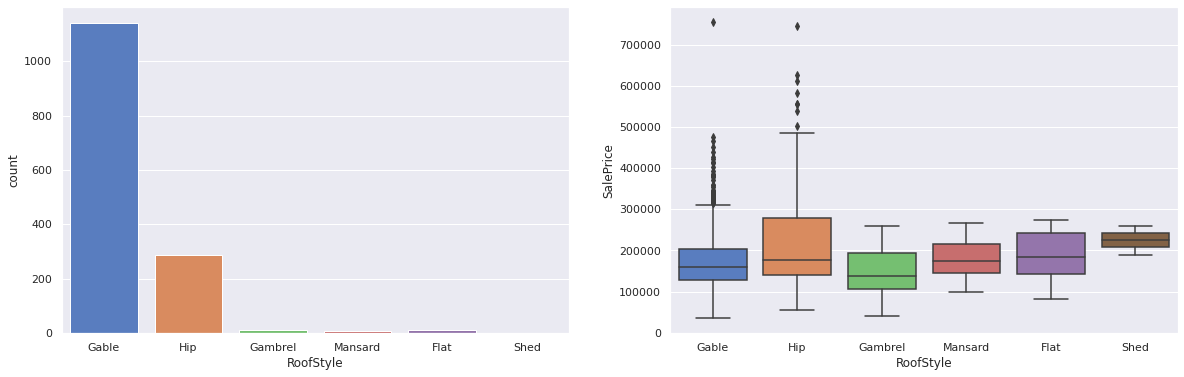

In [18]:
categorial_feature_overview('RoofStyle')

# RoofMatl

Roof material

* ClyTile - Clay or Tile
* CompShg - Standard (Composite) Shingle
* Membran - Membrane
* Metal - Metal
* Roll - Roll
* Tar&Grv - Gravel & Tar
* WdShake - Wood Shakes
* WdShngl - Wood Shingles

RoofMatl has 0.0 % of null values


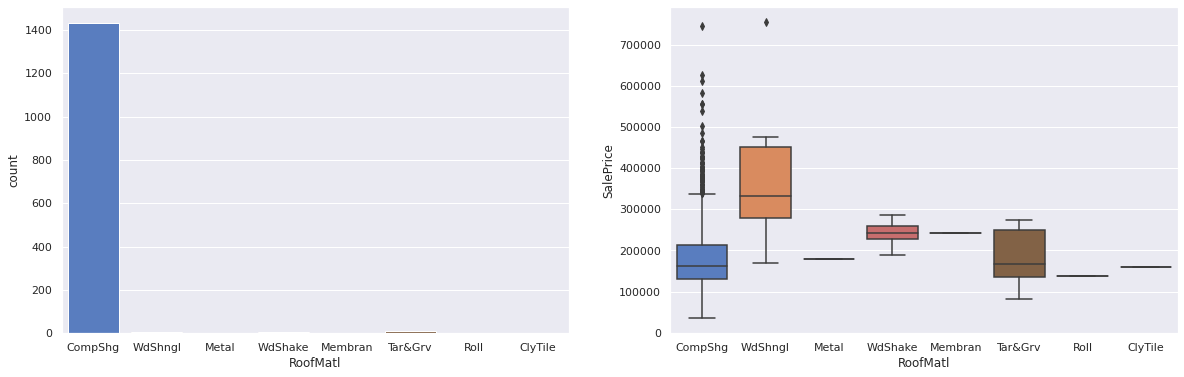

In [19]:
categorial_feature_overview('RoofMatl')

# Exterior1st

Exterior covering on house

* AsbShng - Asbestos Shingles
* AsphShn - Asphalt Shingles
* BrkComm - Brick Common
* BrkFace - Brick Face
* CBlock - Cinder Block
* CemntBd - Cement Board
* HdBoard - Hard Board
* ImStucc - Imitation Stucco
* MetalSd - Metal Siding
* Other - Other
* Plywood - Plywood
* PreCast - PreCast
* Stone - Stone
* Stucco - Stucco
* VinylSd - Vinyl Siding
* Wd Sdng - Wood Siding
* WdShing - Wood Shingles

Exterior1st has 0.0 % of null values


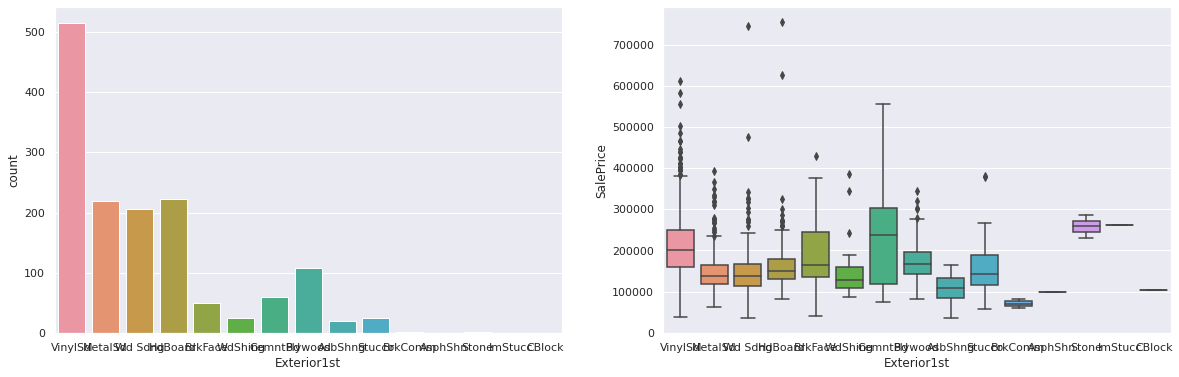

In [20]:
categorial_feature_overview('Exterior1st')

# Exterior2nd

Exterior covering on house (if more than one material)

* AsbShng - Asbestos Shingles
* AsphShn - Asphalt Shingles
* BrkComm - Brick Common
* BrkFace - Brick Face
* CBlock - Cinder Block
* CemntBd - Cement Board
* HdBoard - Hard Board
* ImStucc - Imitation Stucco
* MetalSd - Metal Siding
* Other - Other
* Plywood - Plywood
* PreCast - PreCast
* Stone - Stone
* Stucco - Stucco
* VinylSd - Vinyl Siding
* Wd Sdng - Wood Siding
* WdShing - Wood Shingles

Exterior2nd has 0.0 % of null values


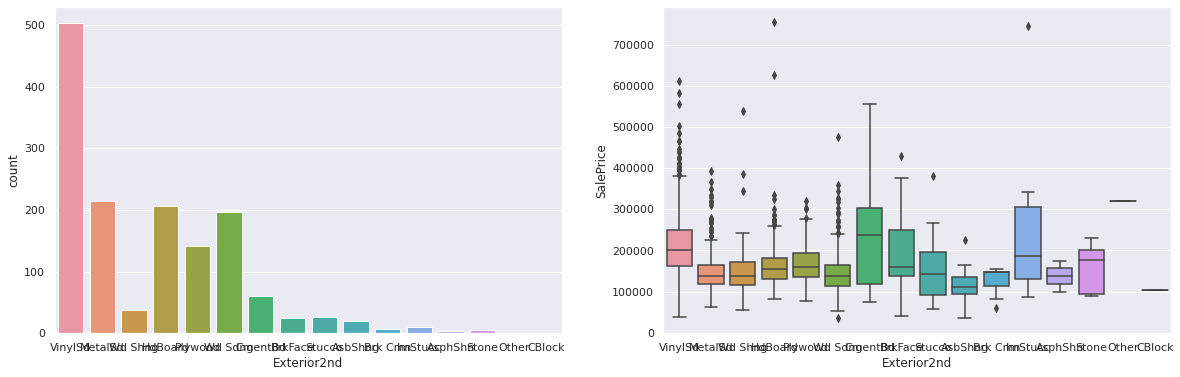

In [21]:
categorial_feature_overview('Exterior2nd')

# MasVnrType

Masonry veneer type

* BrkCmn - Brick Common
* BrkFace - Brick Face
* CBlock - Cinder Block
* None - None
* Stone - Stone

MasVnrType has 0.547945205479452 % of null values


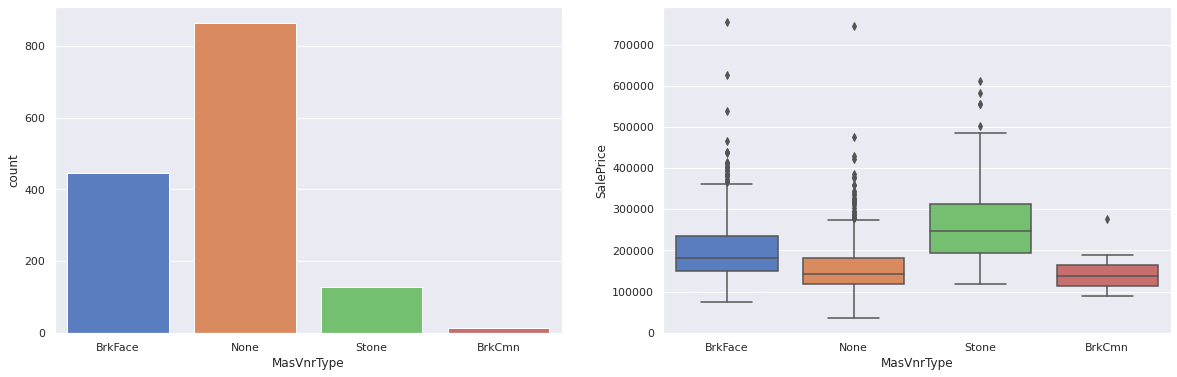

In [22]:
categorial_feature_overview('MasVnrType')

# MasVnrArea

Masonry veneer area in square feet

MasVnrArea has 0.547945205479452 % of null values


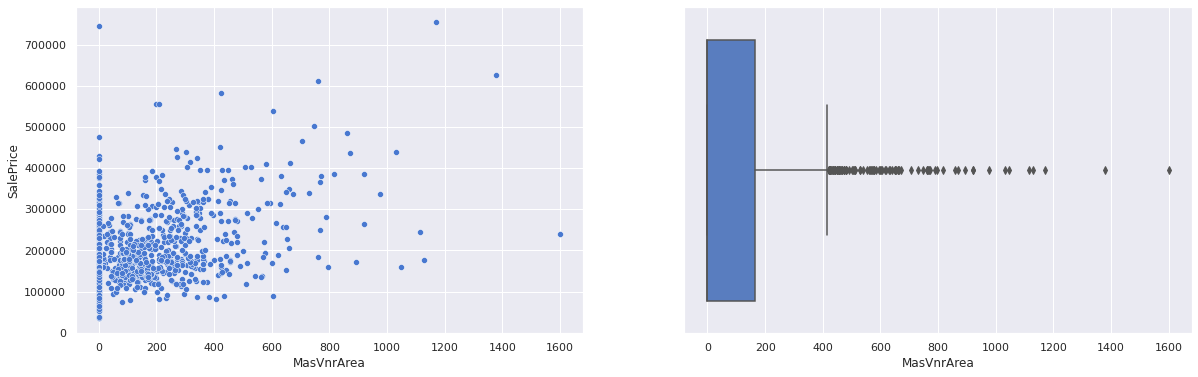

In [23]:
numerical_feature_overview('MasVnrArea')

# ExterQual

Evaluates the quality of the material on the exterior 

* Ex - Excellent
* Gd - Good
* TA - Average/Typical
* Fa - Fair
* Po - Poor

ExterQual has 0.0 % of null values


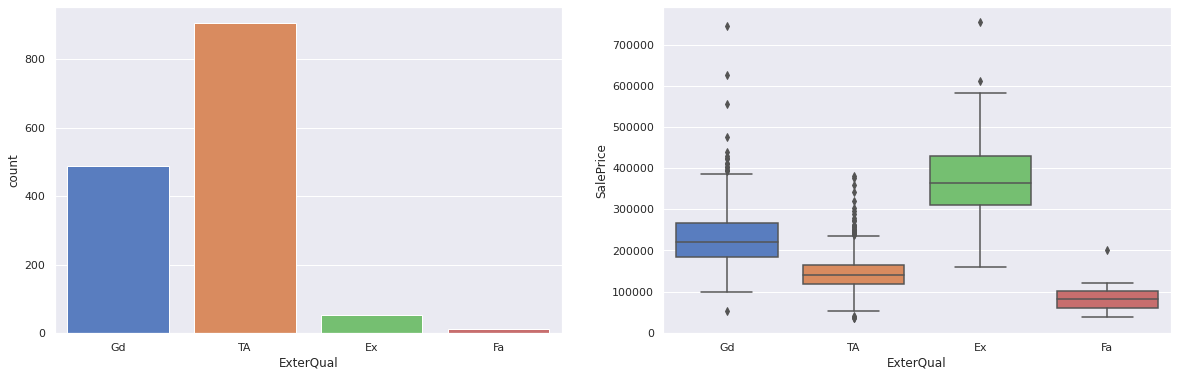

In [24]:
categorial_feature_overview('ExterQual')

# ExterCond

Evaluates the present condition of the material on the exterior

* Ex - Excellent
* Gd - Good
* TA - Average/Typical
* Fa - Fair
* Po - Poor

ExterCond has 0.0 % of null values


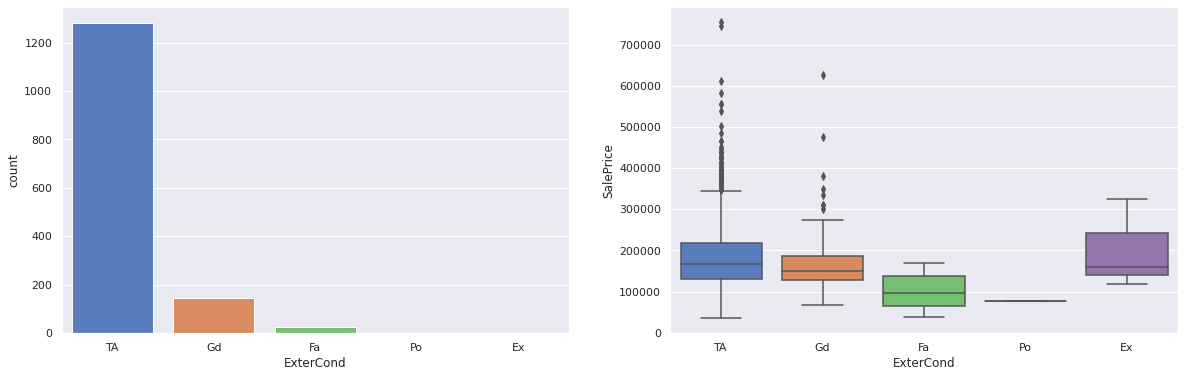

In [25]:
categorial_feature_overview('ExterCond')

# Foundation

Type of foundation

* BrkTil - Brick & Tile
* CBlock - Cinder Block
* PConc - Poured Contrete
* Slab - Slab
* Stone - Stone
* Wood - Wood

Foundation has 0.0 % of null values


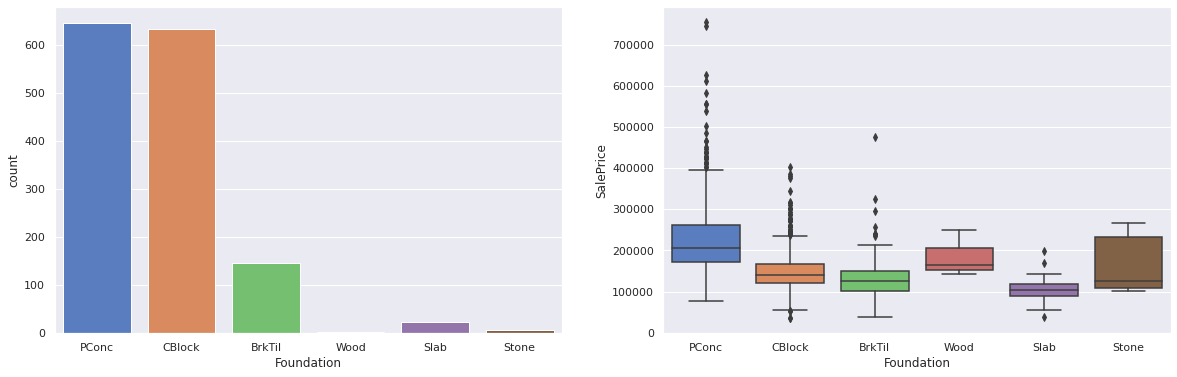

In [26]:
categorial_feature_overview('Foundation')

# BsmtQual

Evaluates the height of the basement

* Ex - Excellent (100+ inches)
* Gd - Good (90-99 inches)
* TA - Typical (80-89 inches)
* Fa - Fair (70-79 inches)
* Po - Poor (<70 inches
* NA - No Basement

BsmtQual has 2.5342465753424657 % of null values


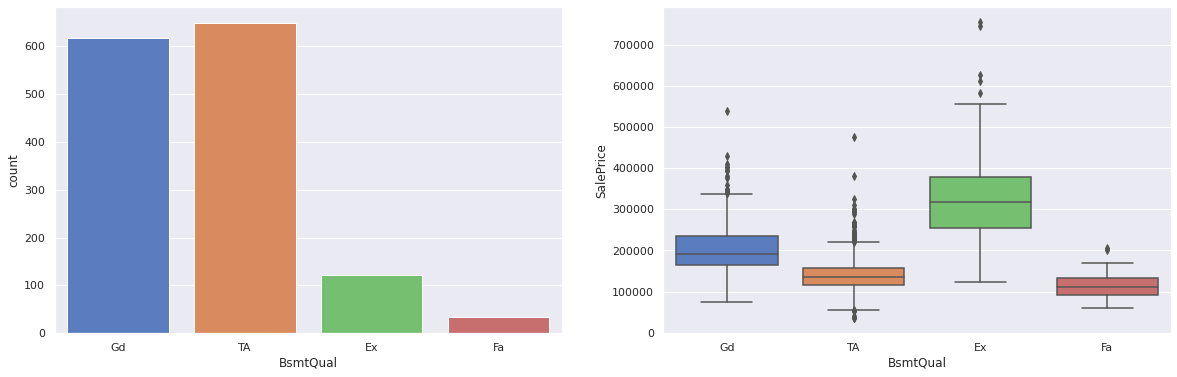

In [27]:
categorial_feature_overview('BsmtQual')

# BsmtCond

Evaluates the general condition of the basement

* Ex - Excellent
* Gd - Good
* TA - Typical - slight dampness allowed
* Fa - Fair - dampness or some cracking or settling
* Po - Poor - Severe cracking, settling, or wetness
* NA - No Basement

BsmtCond has 2.5342465753424657 % of null values


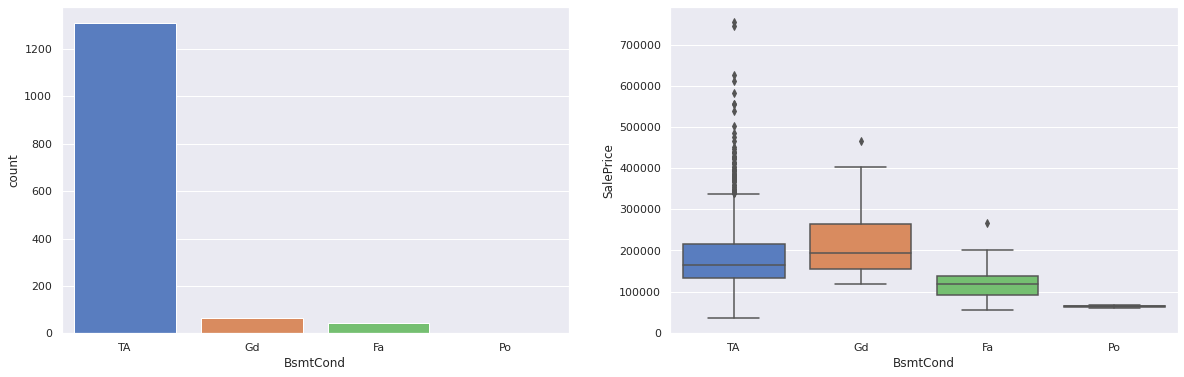

In [28]:
categorial_feature_overview('BsmtCond')

# BsmtExposure

Refers to walkout or garden level walls

* Gd - Good Exposure
* Av - Average Exposure (split levels or foyers typically score average or above)	
* Mn - Mimimum Exposure
* No - No Exposure
* NA - No Basement

BsmtExposure has 2.6027397260273974 % of null values


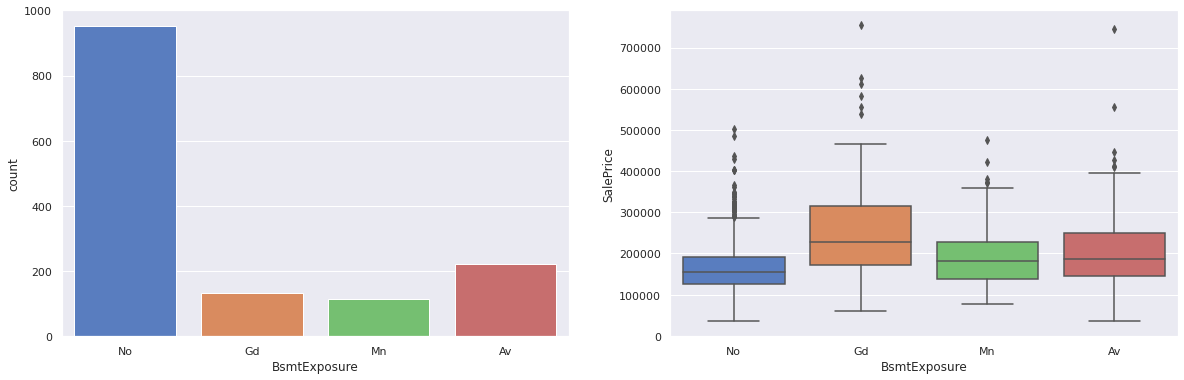

In [29]:
categorial_feature_overview('BsmtExposure')

# BsmtFinType1

Rating of basement finished area

* GLQ - Good Living Quarters
* ALQ - Average Living Quarters
* BLQ - Below Average Living Quarters
* Rec - Average Rec Room
* LwQ - Low Quality
* Unf - Unfinshed
* NA - No Basement

BsmtFinType1 has 2.5342465753424657 % of null values


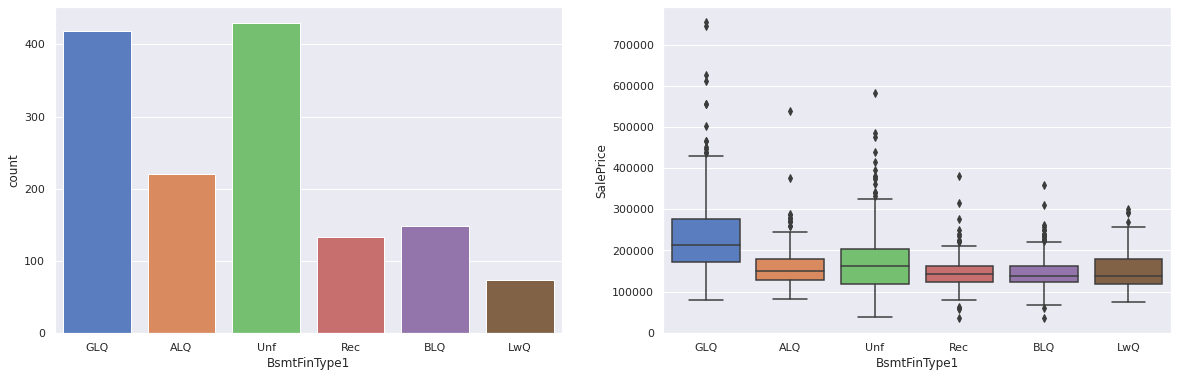

In [30]:
categorial_feature_overview('BsmtFinType1')

# BsmtFinType2

Rating of basement finished area (if multiple types)

* GLQ - Good Living Quarters
* ALQ - Average Living Quarters
* BLQ - Below Average Living Quarters
* Rec - Average Rec Room
* LwQ - Low Quality
* Unf - Unfinshed
* NA - No Basement

BsmtFinType2 has 2.6027397260273974 % of null values


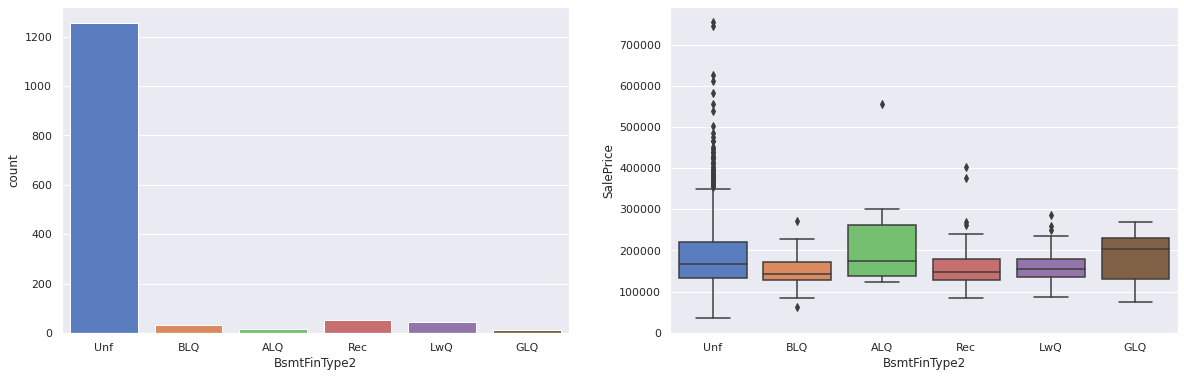

In [31]:
categorial_feature_overview('BsmtFinType2')

# BsmtFinSF1

Type 1 finished square feet

BsmtFinSF1 has 0.0 % of null values


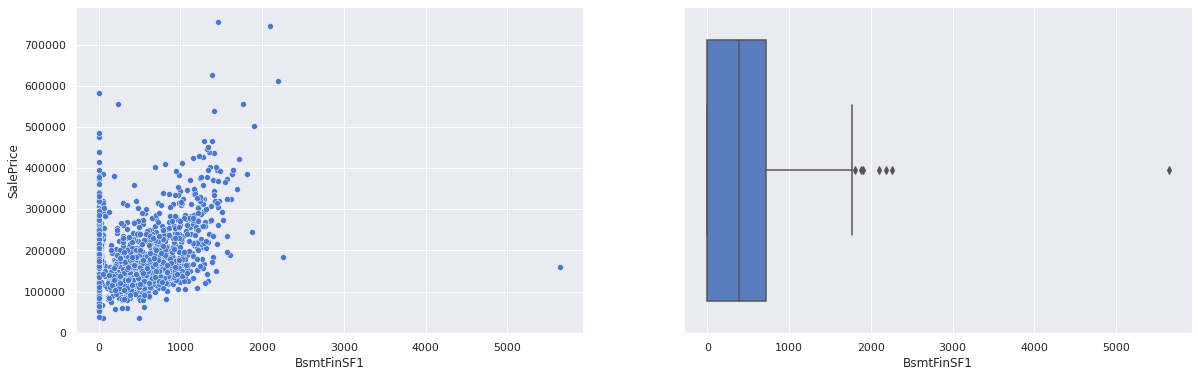

In [32]:
numerical_feature_overview('BsmtFinSF1')

# BsmtFinSF2

Type 2 finished square feet

BsmtFinSF2 has 0.0 % of null values


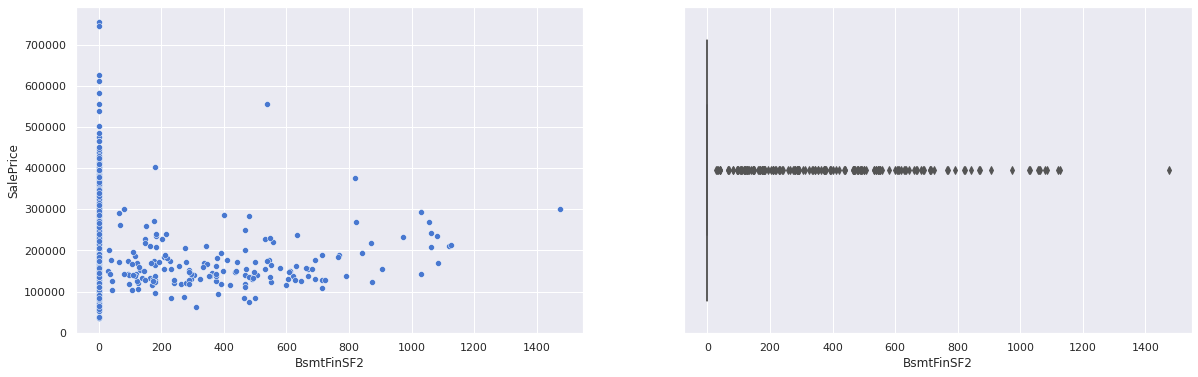

In [33]:
numerical_feature_overview('BsmtFinSF2')

# BsmtUnfSF

Unfinished square feet of basement area

BsmtUnfSF has 0.0 % of null values


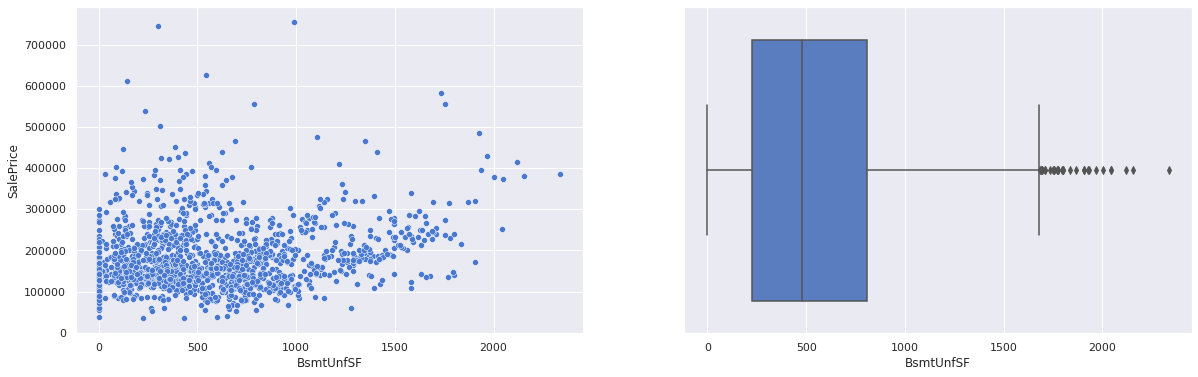

In [34]:
numerical_feature_overview('BsmtUnfSF')

# TotalBsmtSF

Total square feet of basement area

TotalBsmtSF has 0.0 % of null values


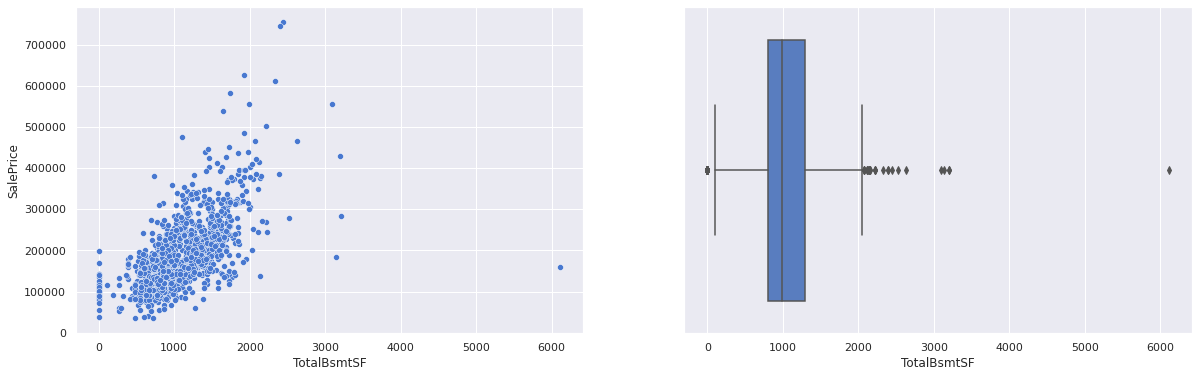

In [35]:
numerical_feature_overview('TotalBsmtSF')

# BedroomAbvGr

BedroomAbvGr has 0.0 % of null values


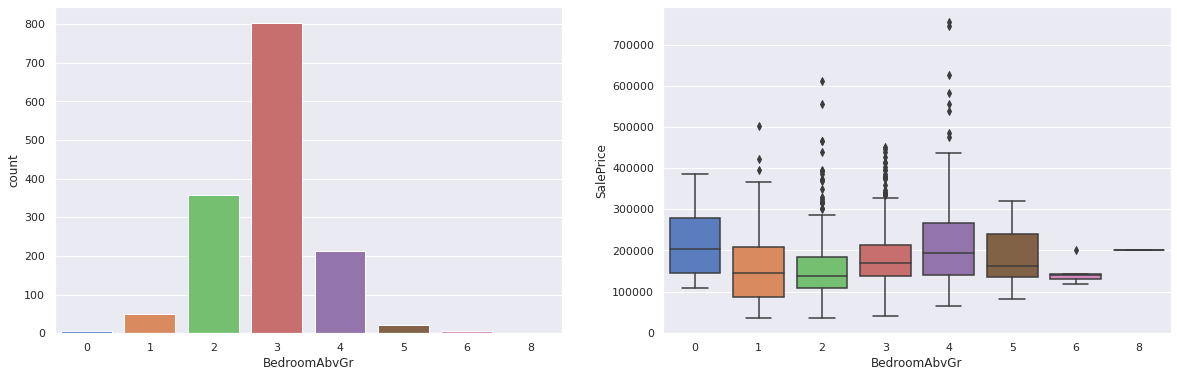

In [36]:
categorial_feature_overview('BedroomAbvGr')

# KitchenAbvGr

KitchenAbvGr has 0.0 % of null values


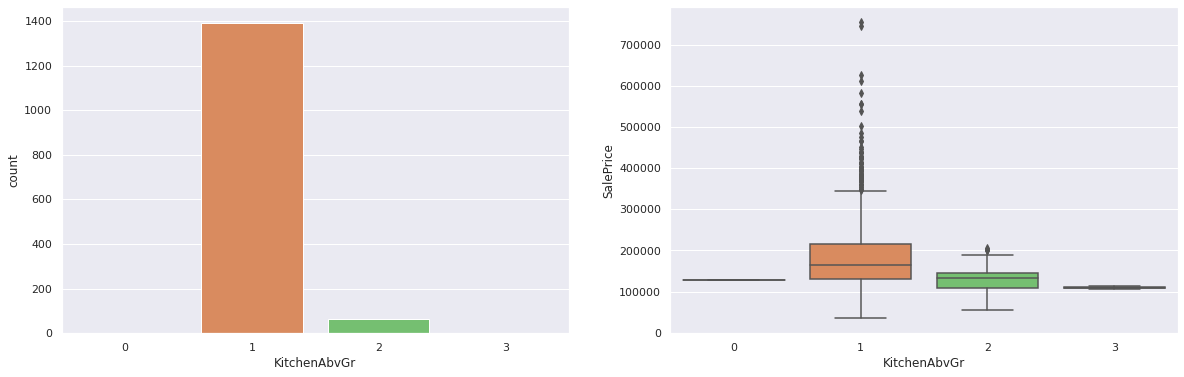

In [37]:
categorial_feature_overview('KitchenAbvGr')

# KitchenQual

Kitchen quality

* Ex - 	Excellent
* Gd - Good
* TA - Typical/Average
* Fa - Fair
* Po - Poor

KitchenQual has 0.0 % of null values


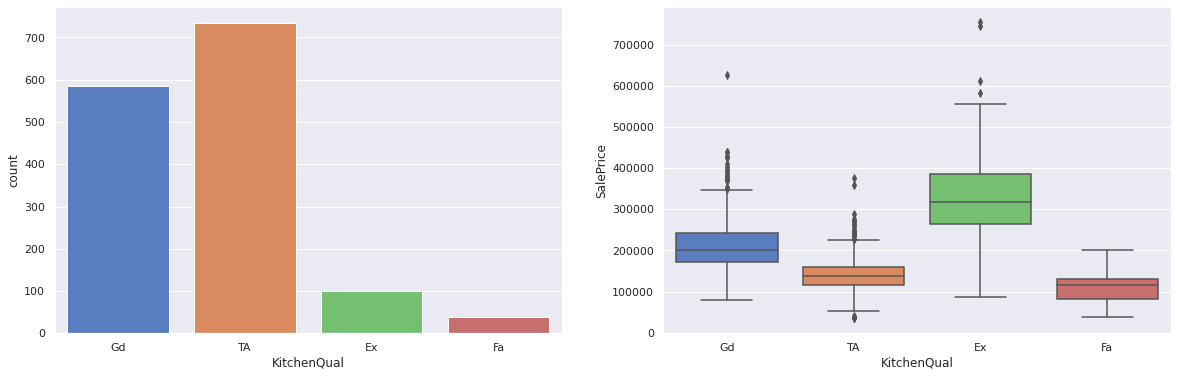

In [38]:
categorial_feature_overview('KitchenQual')

# TotRmsAbvGrd

Total rooms above grade (does not include bathrooms)

TotRmsAbvGrd has 0.0 % of null values


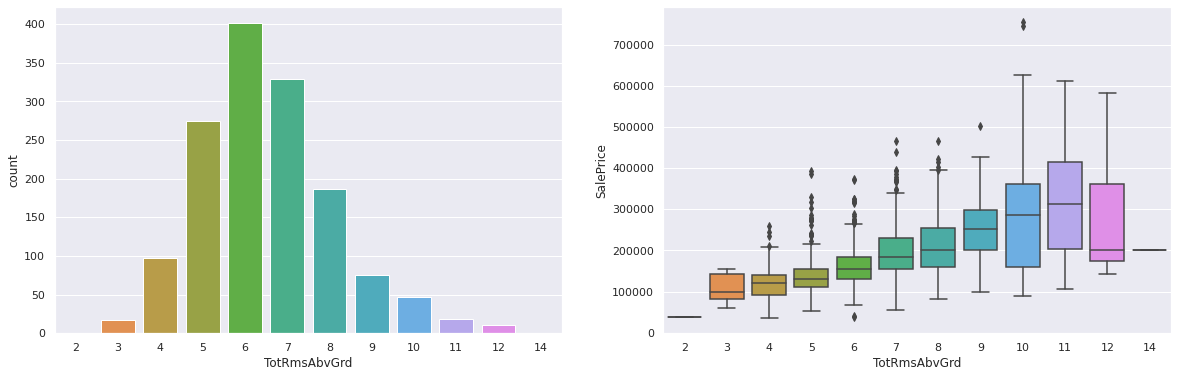

In [39]:
categorial_feature_overview('TotRmsAbvGrd')

# Functional

Home functionality (Assume typical unless deductions are warranted)

* Typ - Typical Functionality
* Min1 - Minor Deductions 1
* Min2 - Minor Deductions 2
* Mod - Moderate Deductions
* Maj1 - Major Deductions 1
* Maj2 - Major Deductions 2
* Sev - Severely Damaged
* Sal - Salvage only

Functional has 0.0 % of null values


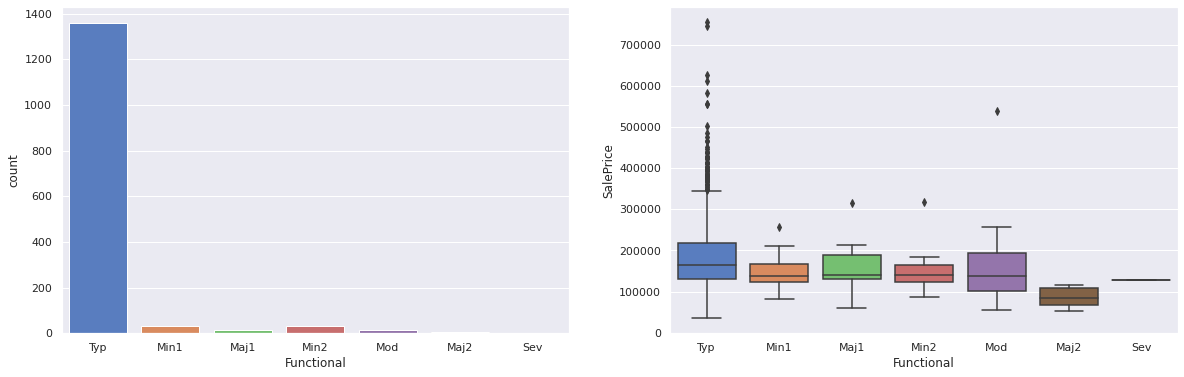

In [40]:
categorial_feature_overview('Functional')

# Fireplaces

Number of fireplaces

Fireplaces has 0.0 % of null values


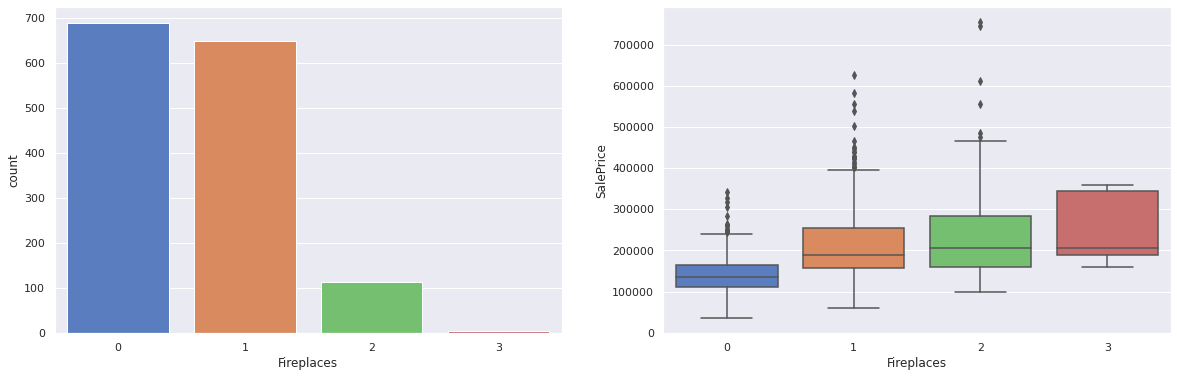

In [41]:
categorial_feature_overview('Fireplaces')

# FireplaceQu

Fireplace quality

* Ex - Excellent - Exceptional Masonry Fireplace
* Gd - Good - Masonry Fireplace in main level
* TA - Average - Prefabricated Fireplace in main living area or Masonry Fireplace in basement
* Fa - Fair - Prefabricated Fireplace in basement
* Po - Poor - Ben Franklin Stove
* NA - No Fireplace

FireplaceQu has 47.26027397260274 % of null values


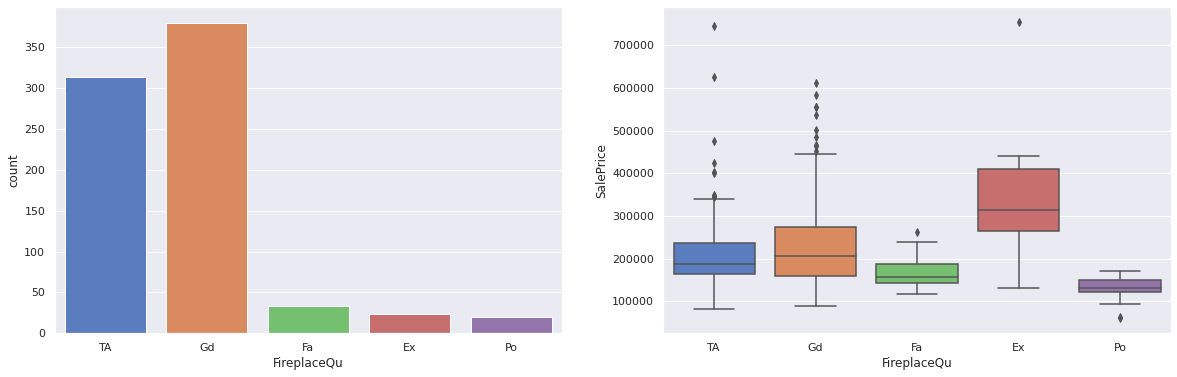

In [42]:
categorial_feature_overview('FireplaceQu')

# GarageType

Garage location

* 2Types - More than one type of garage
* Attchd - Attached to home
* Basment - Basement Garage
* BuiltIn - Built-In (Garage part of house - typically has room above garage)
* CarPort - Car Port
* Detchd - Detached from home
* NA - No Garage

GarageType has 5.5479452054794525 % of null values


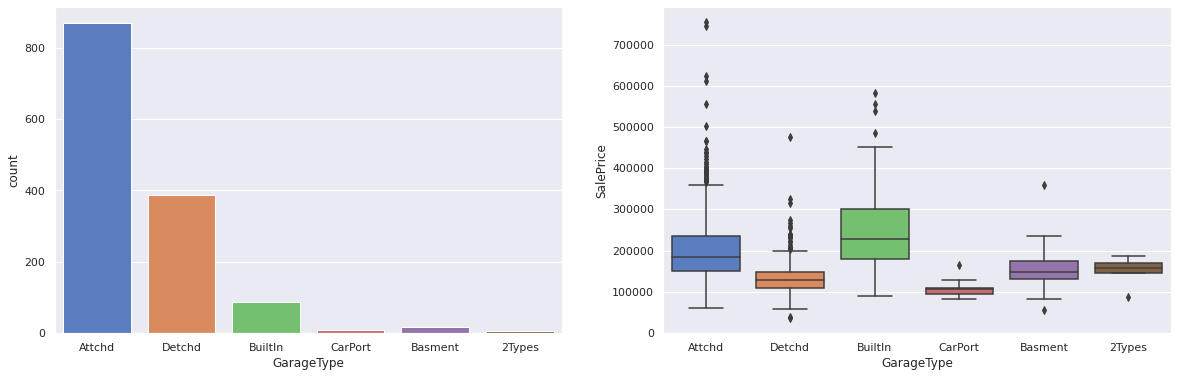

In [43]:
categorial_feature_overview('GarageType')

# GarageYrBlt

Year garage was built

GarageYrBlt has 5.5479452054794525 % of null values


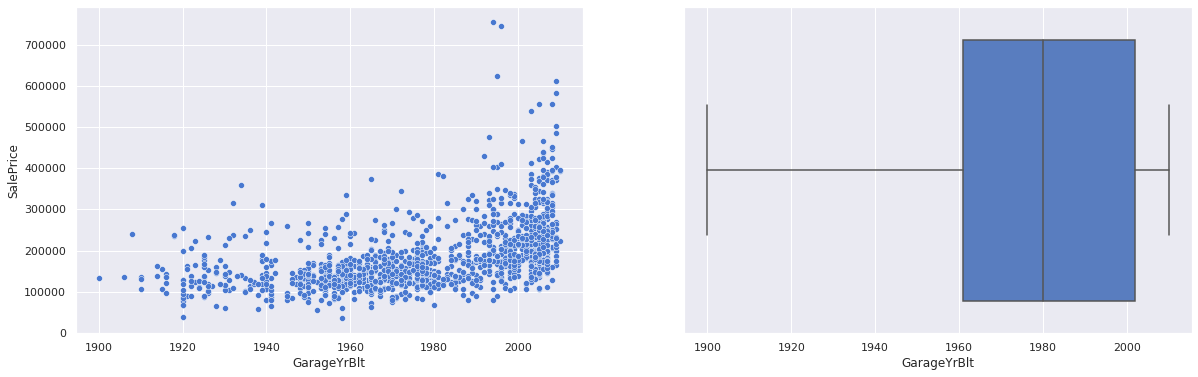

In [44]:
numerical_feature_overview('GarageYrBlt')

# GarageFinish

Interior finish of the garage

* Fin - Finished
* RFn - Rough Finished
* Unf - Unfinished
* NA - No Garage

GarageFinish has 5.5479452054794525 % of null values


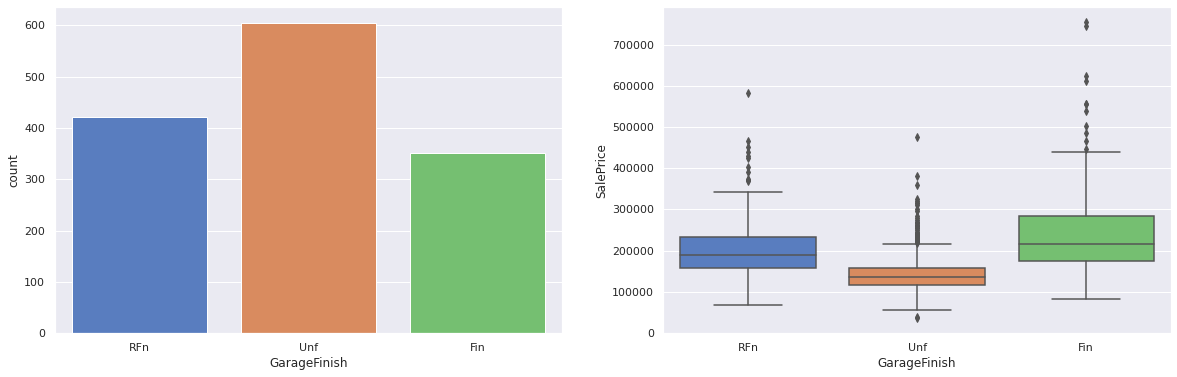

In [45]:
categorial_feature_overview('GarageFinish')

# GarageCars

Size of garage in car capacity

GarageCars has 0.0 % of null values


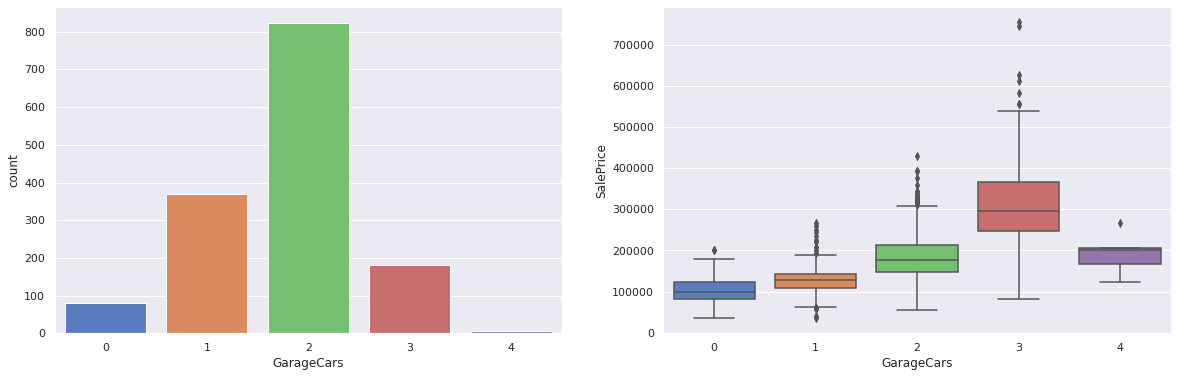

In [46]:
categorial_feature_overview('GarageCars')

# GarageArea

Size of garage in square feet

GarageArea has 0.0 % of null values


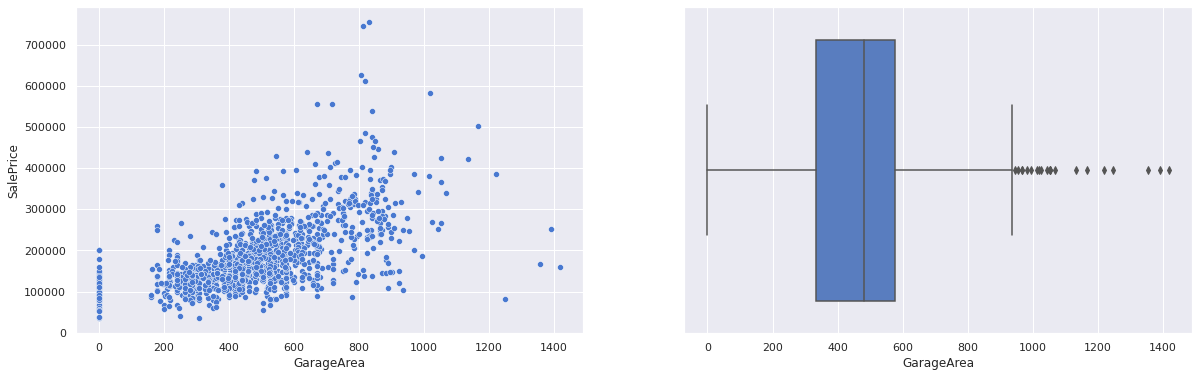

In [47]:
numerical_feature_overview('GarageArea')

# GarageQual

Garage quality

* Ex - Excellent
* Gd - Good
* TA - Typical/Average
* Fa - Fair
* Po - Poor
* NA - No Garage

GarageCond has 5.5479452054794525 % of null values


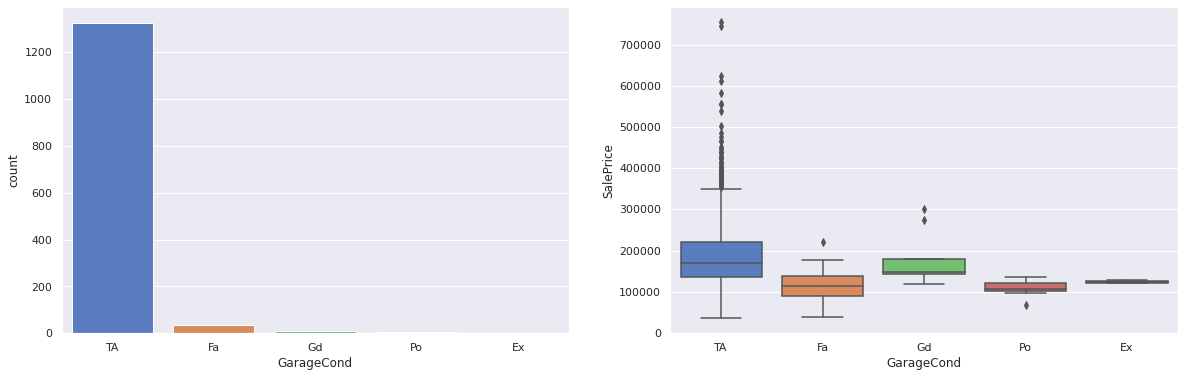

In [48]:
categorial_feature_overview('GarageCond')

# GarageCond

Garage condition

* Ex - Excellent
* Gd - Good
* TA - Typical/Average
* Fa - Fair
* Po - Poor
* NA - No Garage

GarageCond has 5.5479452054794525 % of null values


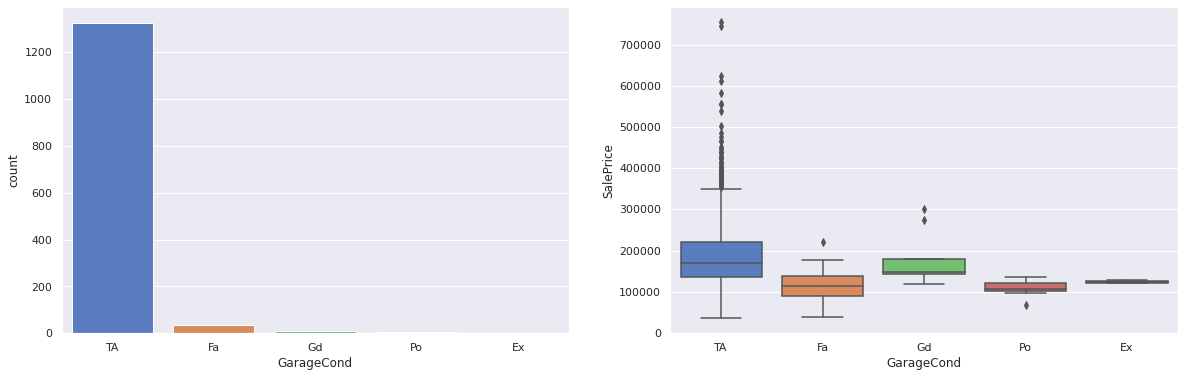

In [49]:
categorial_feature_overview('GarageCond')

# PavedDrive

Paved driveway

* Y - Paved 
* P - Partial Pavement
* N - Dirt/Gravel

PavedDrive has 0.0 % of null values


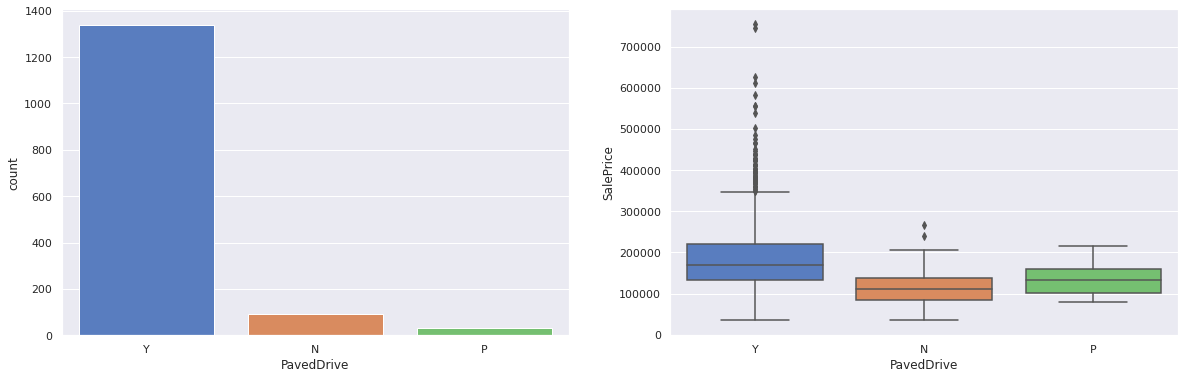

In [50]:
categorial_feature_overview('PavedDrive')

# BldgType

Type of dwelling

* 1Fam - Single-family Detached
* 2FmCon - Two-family Conversion; originally built as one-family dwelling
* Duplx - Duplex
* TwnhsE - Townhouse End Unit
* TwnhsI - Townhouse Inside Unit

BldgType has 0.0 % of null values


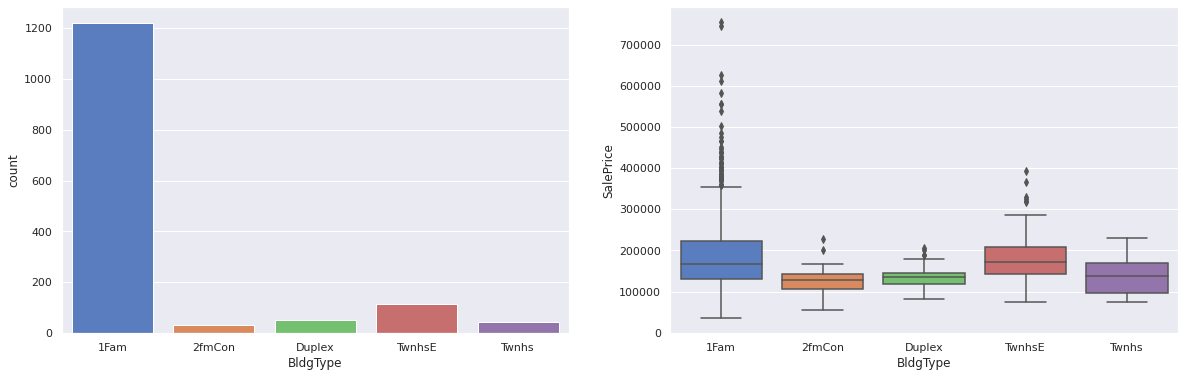

In [51]:
categorial_feature_overview('BldgType')

# HouseStyle

Style of dwelling
* 1Story - One story
* 1.5Fin - One and one-half story: 2nd level finished
* 1.5Unf - One and one-half story: 2nd level unfinished
* 2Story - Two story
* 2.5Fin - Two and one-half story: 2nd level finished
* 2.5Unf - Two and one-half story: 2nd level unfinished
* SFoyer - Split Foyer
* SLvl - Split Level

HouseStyle has 0.0 % of null values


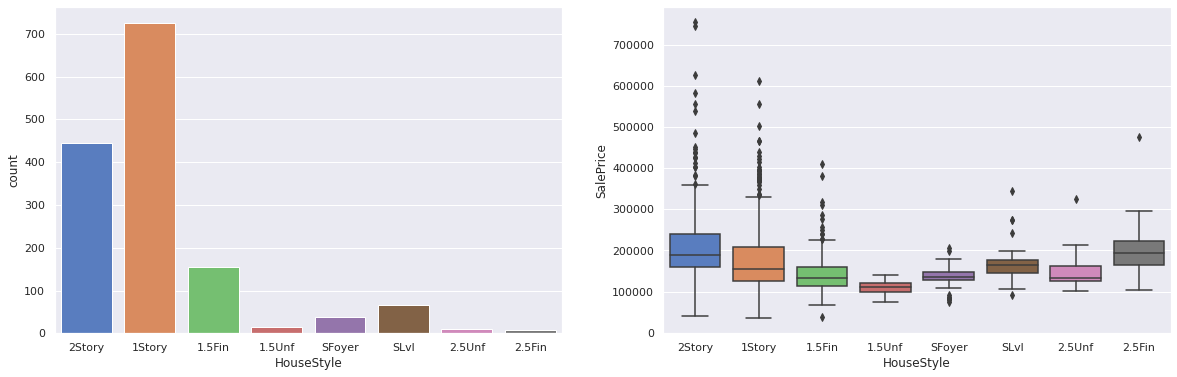

In [52]:
categorial_feature_overview('HouseStyle')

# OverallQual

Rates the overall material and finish of the house

* 10 - Very Excellent
* 9 - Excellent
* 8 - Very Good
* 7 - Good
* 6 - Above Average
* 5 - Average
* 4 - Below Average
* 3 - Fair
* 2 - Poor
* 1 - Very Poor

OverallQual has 0.0 % of null values


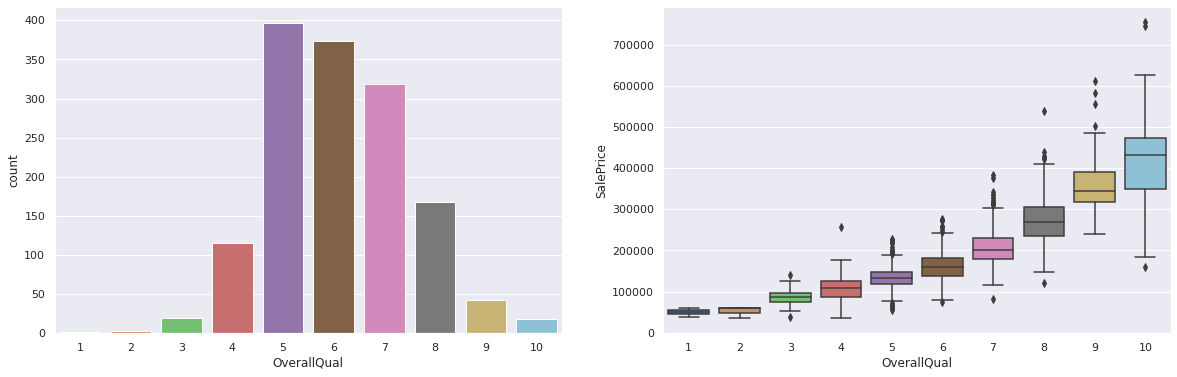

In [53]:
categorial_feature_overview('OverallQual')

# OverallCond

Rates the overall condition of the house

* 10 - Very Excellent
* 9 - Excellent
* 8 - Very Good
* 7 - Good
* 6 - Above Average
* 5 - Average
* 4 - Below Average
* 3 - Fair
* 2 - Poor
* 1 - Very Poor

OverallCond has 0.0 % of null values


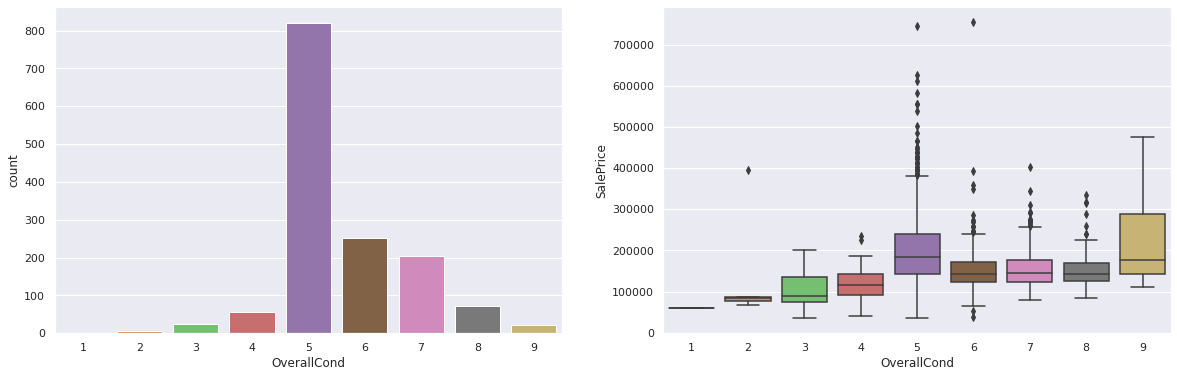

In [54]:
categorial_feature_overview('OverallCond')

# YearBuilt

Original construction date

YearBuilt has 0.0 % of null values


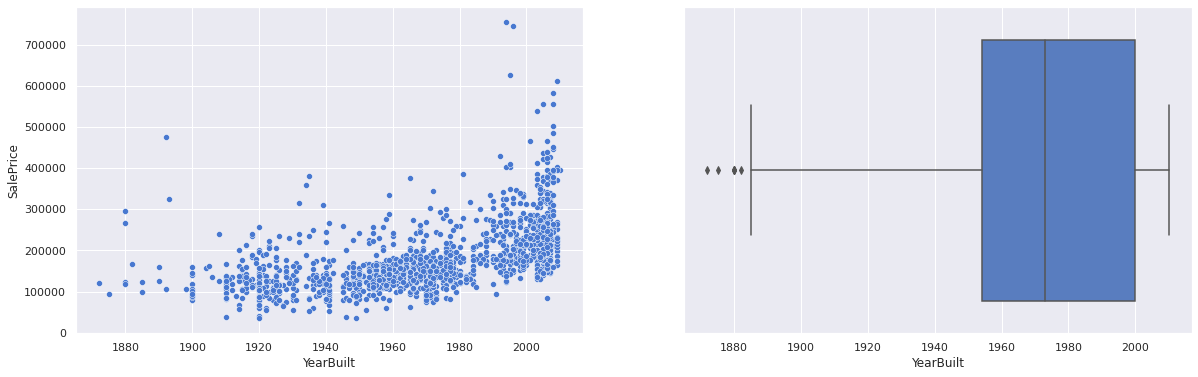

In [55]:
numerical_feature_overview('YearBuilt')

# YearRemodAdd

Remodel date (same as construction date if no remodeling or additions)

YearRemodAdd has 0.0 % of null values


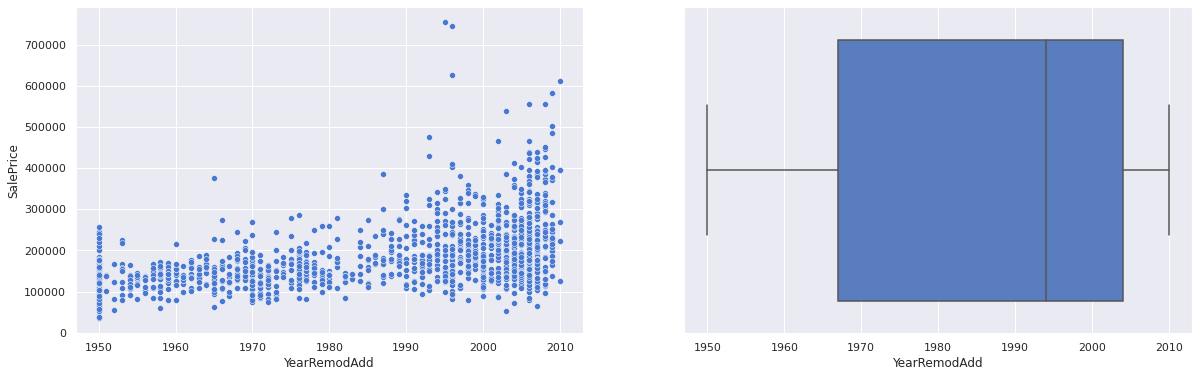

In [56]:
numerical_feature_overview('YearRemodAdd')

# Heating
Type of heating

* Floor - Floor Furnace
* GasA - Gas forced warm air furnace
* GasW - Gas hot water or steam heat
* Grav - Gravity furnace
* OthW - Hot water or steam heat other than gas
* Wall - Wall furnace


Heating has 0.0 % of null values


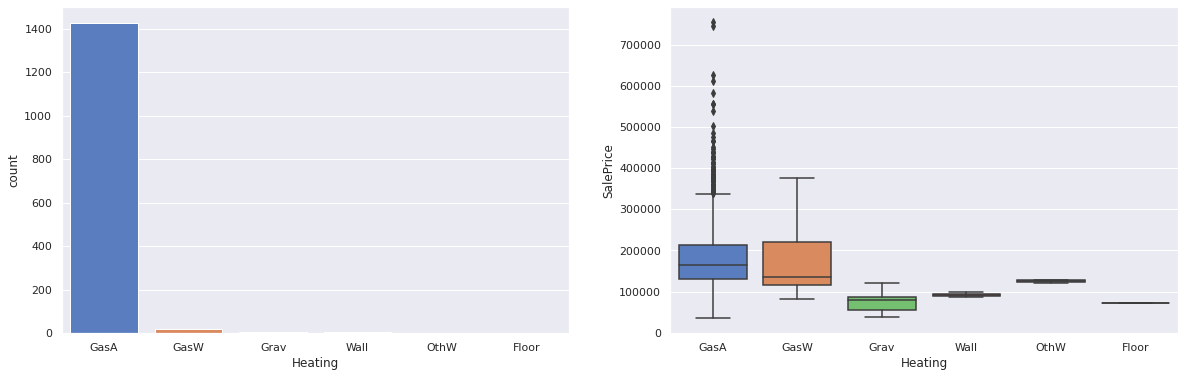

In [57]:
categorial_feature_overview('Heating')

# HeatingQC

Heating quality and condition

* Ex - Excellent
* Gd - Good
* TA - Average/Typical
* Fa - Fair
* Po - Poor

HeatingQC has 0.0 % of null values


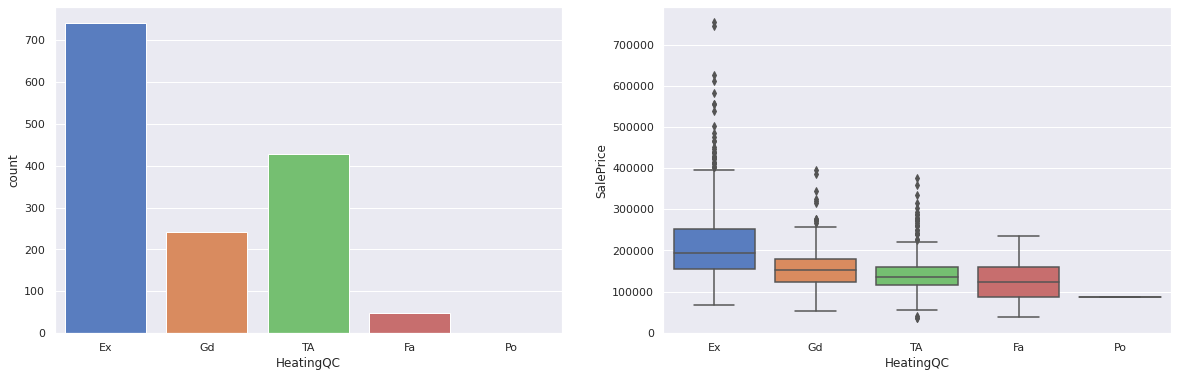

In [58]:
categorial_feature_overview('HeatingQC')

# CentralAir

Central air conditioning

 * N - No
 * Y - Yes

CentralAir has 0.0 % of null values


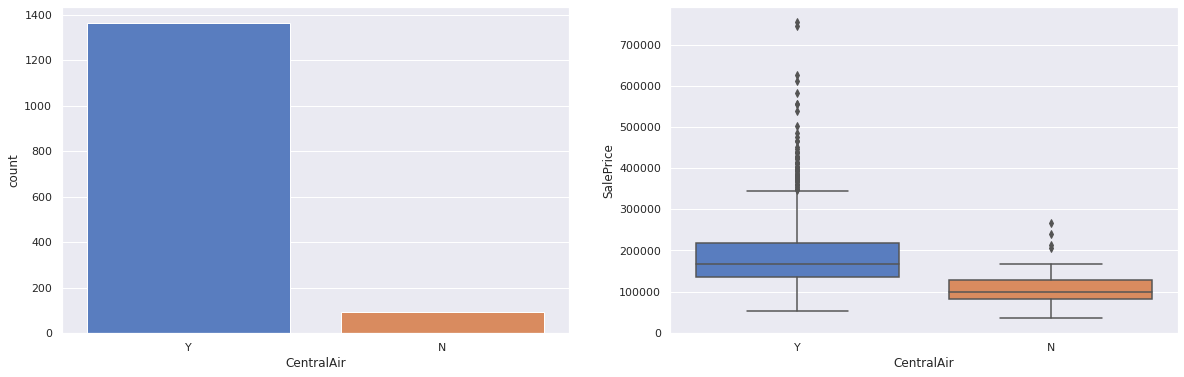

In [59]:
categorial_feature_overview('CentralAir')

# Electrical

Electrical system

* SBrkr - Standard Circuit Breakers & Romex
* FuseA - Fuse Box over 60 AMP and all Romex wiring (Average)
* FuseF - 60 AMP Fuse Box and mostly Romex wiring (Fair)
* FuseP - 60 AMP Fuse Box and mostly knob & tube wiring (poor)
* Mix - Mixed

Electrical has 0.0684931506849315 % of null values


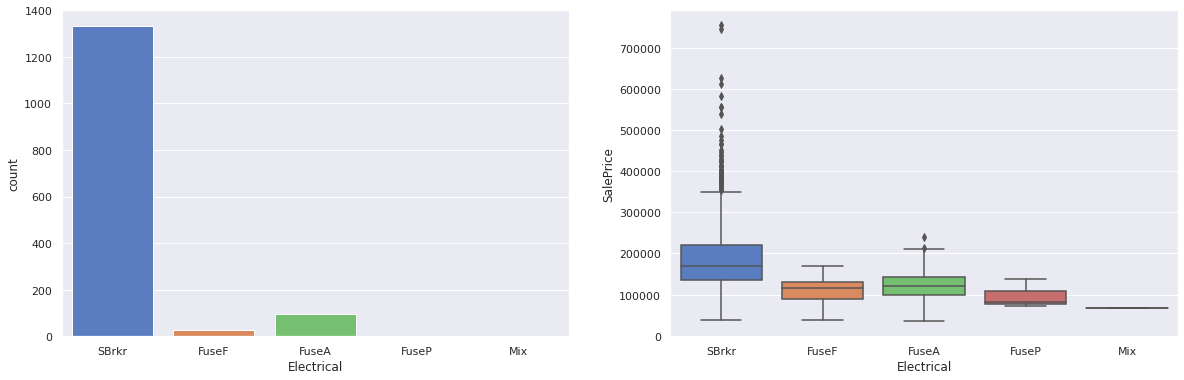

In [60]:
categorial_feature_overview('Electrical')

# 1stFlrSF

First Floor square feet

1stFlrSF has 0.0 % of null values


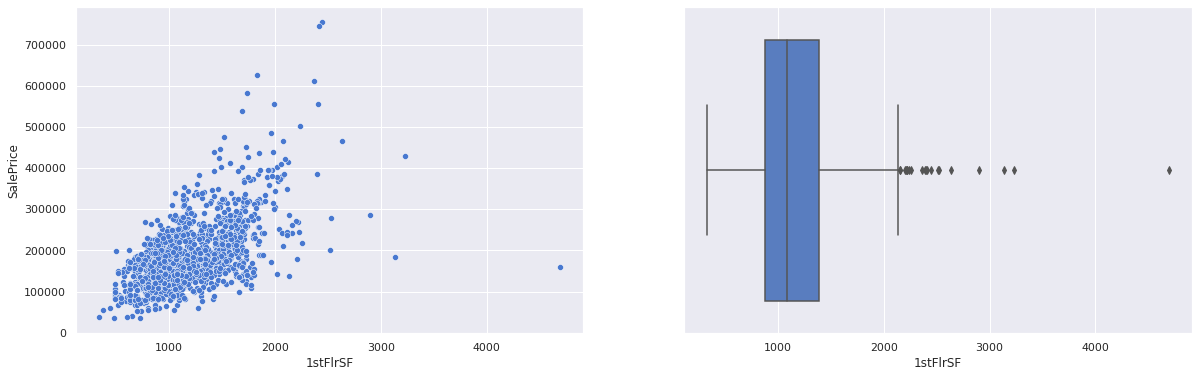

In [61]:
numerical_feature_overview('1stFlrSF')

# 2ndFlrSF

Second floor square feet

2ndFlrSF has 0.0 % of null values


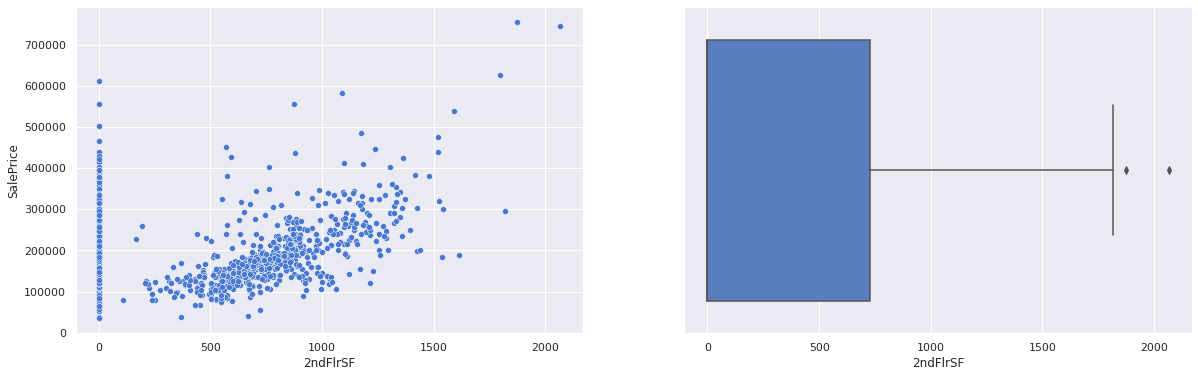

In [62]:
numerical_feature_overview('2ndFlrSF')

# LowQualFinSF

Low quality finished square feet (all floors)

LowQualFinSF has 0.0 % of null values


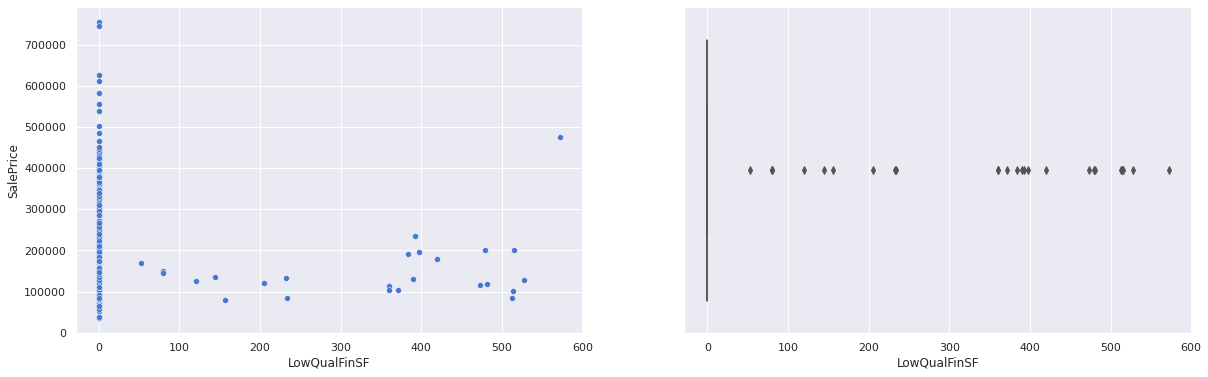

In [63]:
numerical_feature_overview('LowQualFinSF')

# GrLivArea

Above grade (ground) living area square feet

GrLivArea has 0.0 % of null values


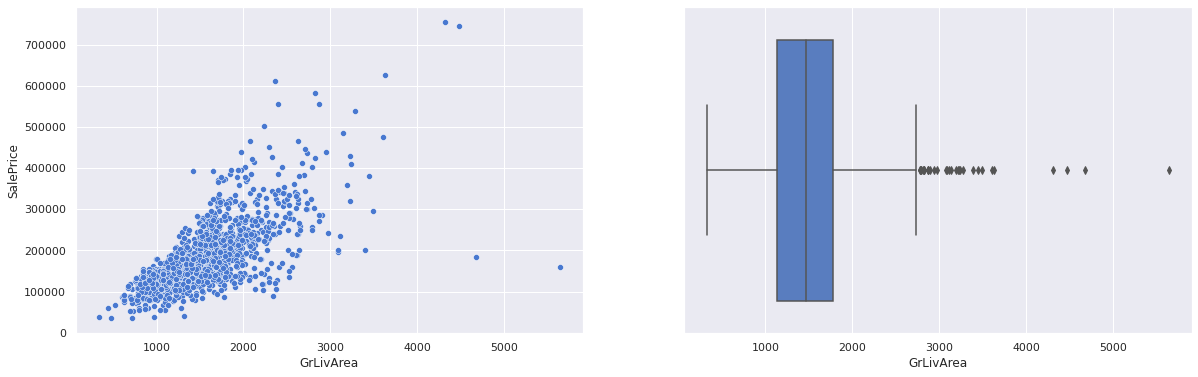

In [64]:
numerical_feature_overview('GrLivArea')

# BsmtFullBath

Basement full bathrooms

BsmtFullBath has 0.0 % of null values


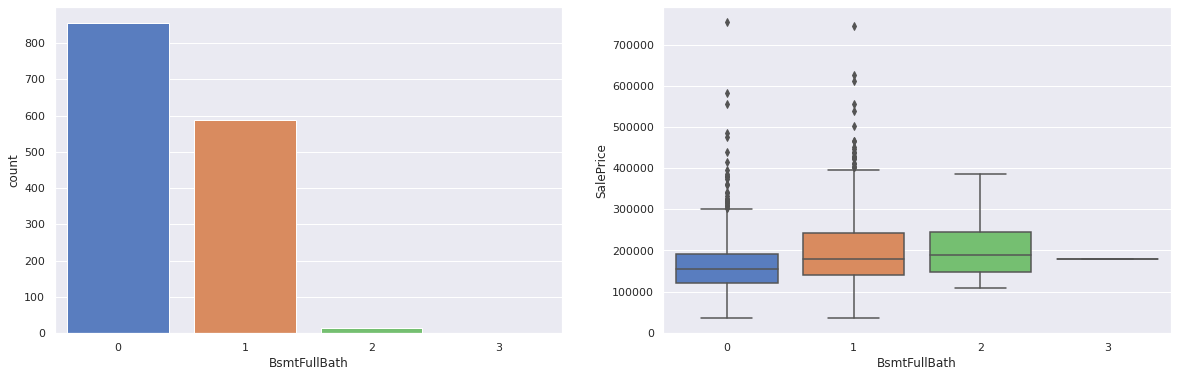

In [65]:
categorial_feature_overview('BsmtFullBath')

# BsmtHalfBath

Basement half bathrooms

BsmtHalfBath has 0.0 % of null values


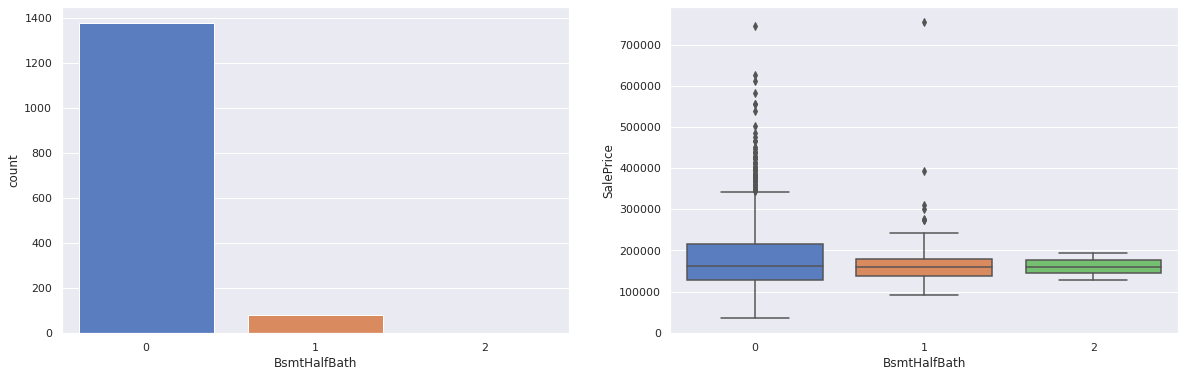

In [66]:
categorial_feature_overview('BsmtHalfBath')

# FullBath

Full bathrooms above grade

FullBath has 0.0 % of null values


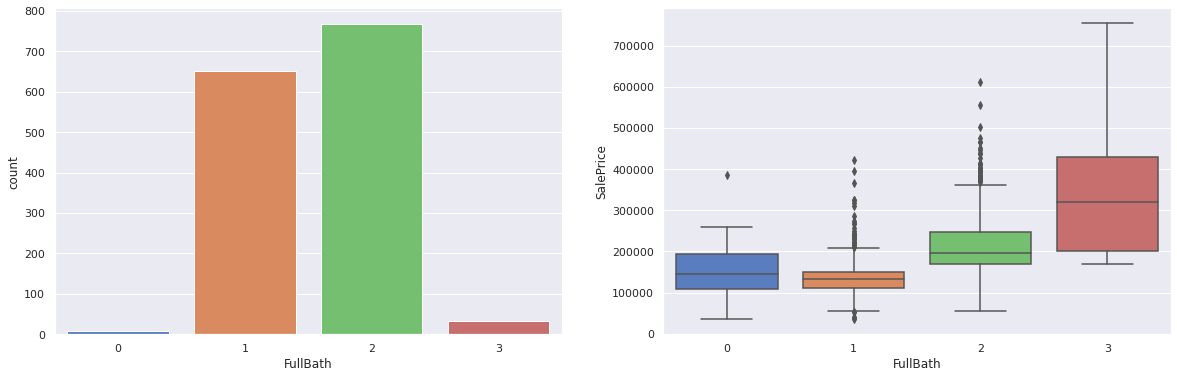

In [67]:
categorial_feature_overview('FullBath')

# HalfBath

Half baths above grade

HalfBath has 0.0 % of null values


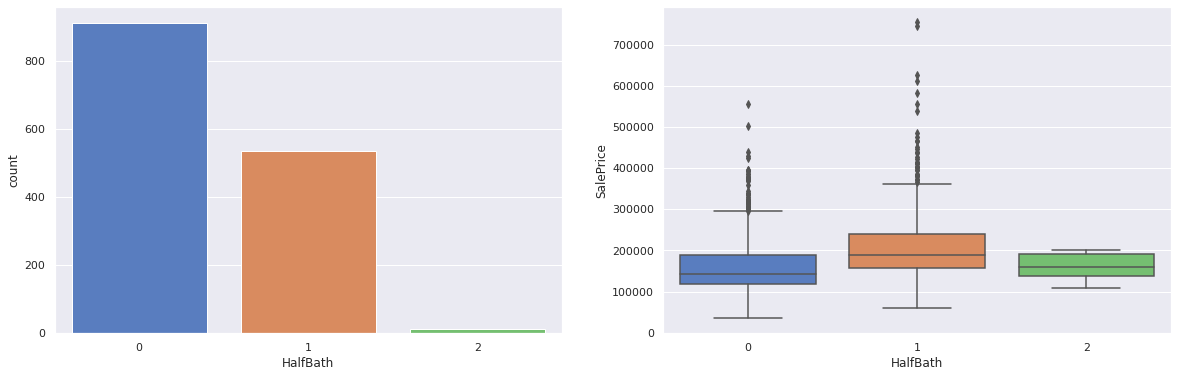

In [68]:
categorial_feature_overview('HalfBath')

# WoodDeckSF

Wood deck area in square feet

WoodDeckSF has 0.0 % of null values


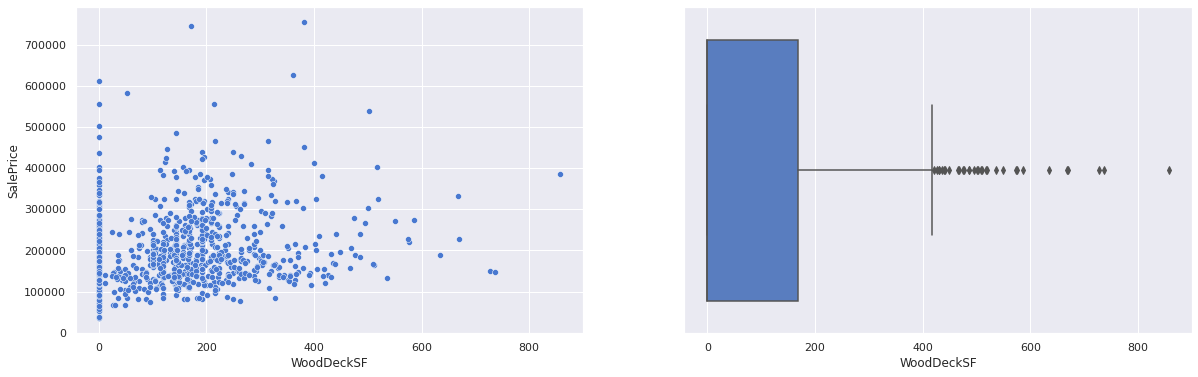

In [69]:
numerical_feature_overview('WoodDeckSF')

# OpenPorchSF

Open porch area in square feet

OpenPorchSF has 0.0 % of null values


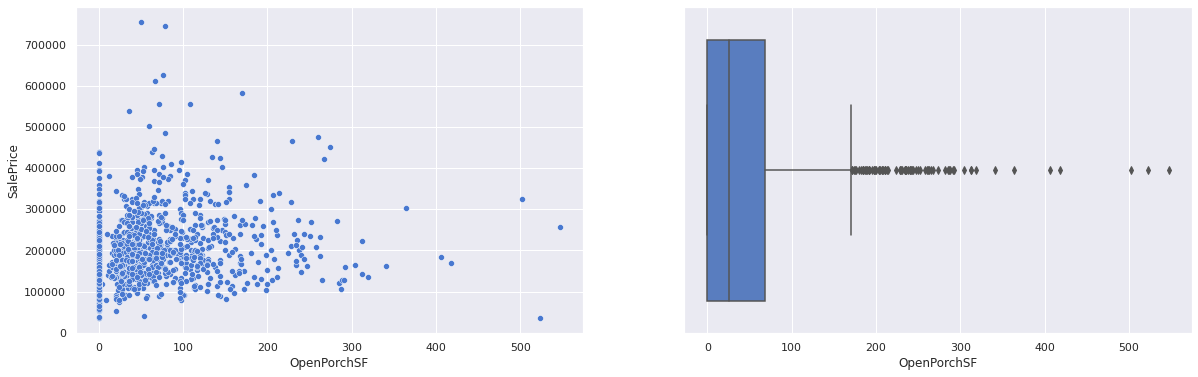

In [70]:
numerical_feature_overview('OpenPorchSF')

# EnclosedPorch

Enclosed porch area in square feet

EnclosedPorch has 0.0 % of null values


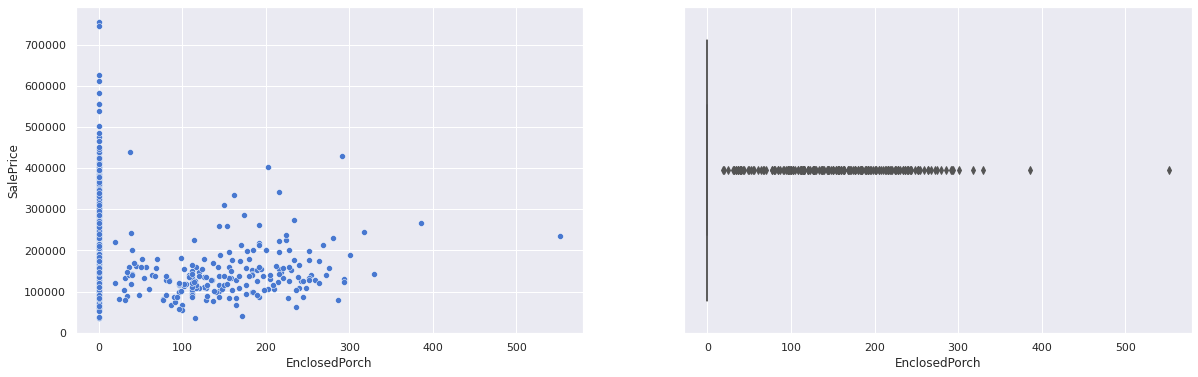

In [71]:
numerical_feature_overview('EnclosedPorch')

# 3SsnPorch

Three season porch area in square feet

3SsnPorch has 0.0 % of null values


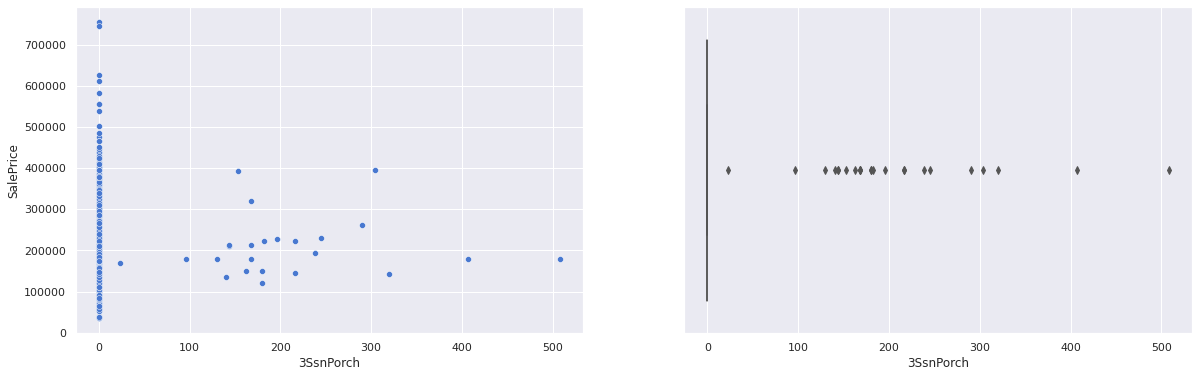

In [72]:
numerical_feature_overview('3SsnPorch')

# ScreenPorch

Screen porch area in square feet

ScreenPorch has 0.0 % of null values


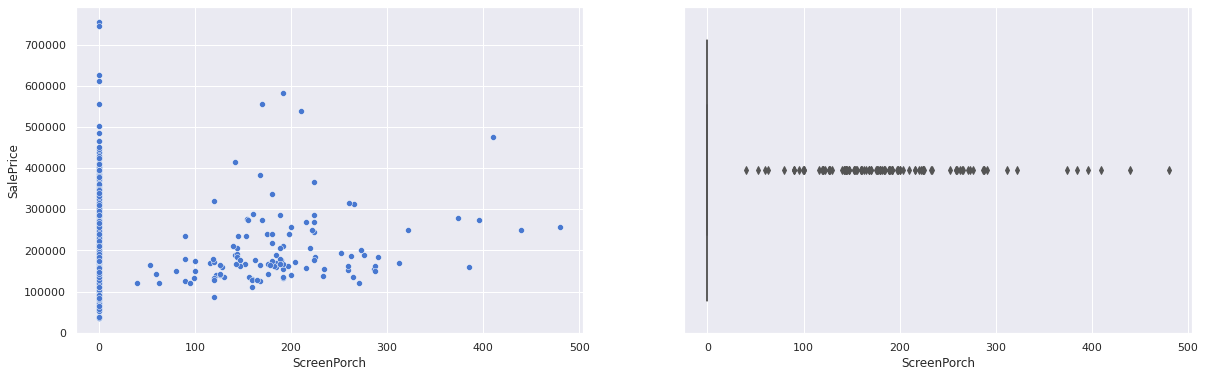

In [73]:
numerical_feature_overview('ScreenPorch')

# PoolArea

Pool area in square feet

PoolArea has 0.0 % of null values


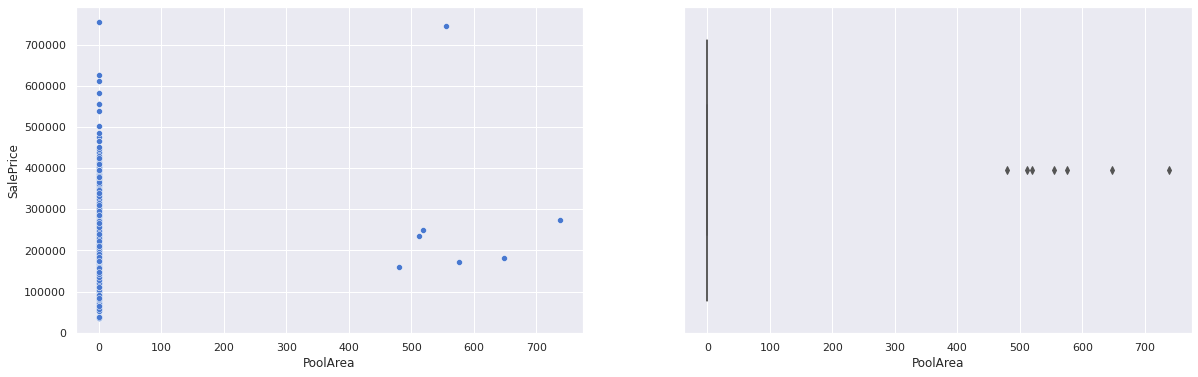

In [74]:
numerical_feature_overview('PoolArea')

# PoolQC

Pool quality

* Ex - Excellent
* Gd - Good
* TA - Average/Typical
* Fa - Fair
* NA - No Pool

PoolQC has 99.52054794520548 % of null values


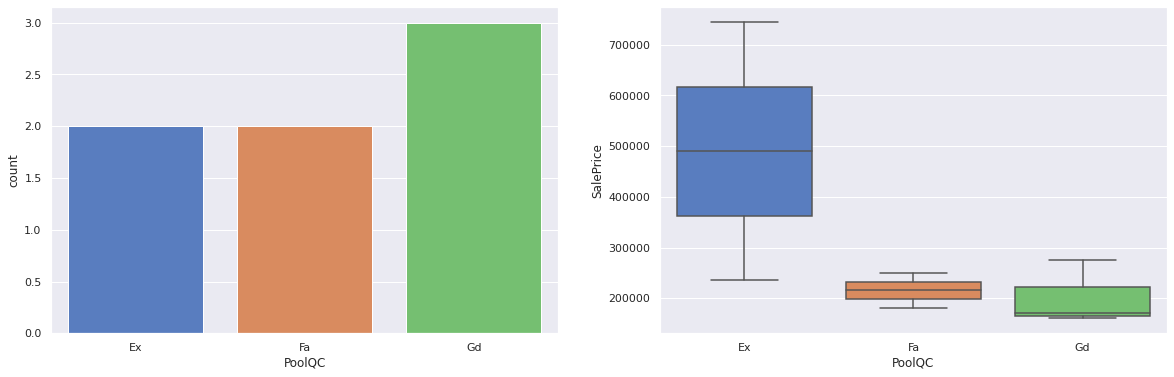

In [75]:
categorial_feature_overview('PoolQC')

# Fence

Fence quality

* GdPrvA - Good Privacy
* MnPrvA - Minimum Privacy
* GdWoA - Good Wood
* MnWwA - Minimum Wood/Wire
* NA - No Fence


Fence has 80.75342465753424 % of null values


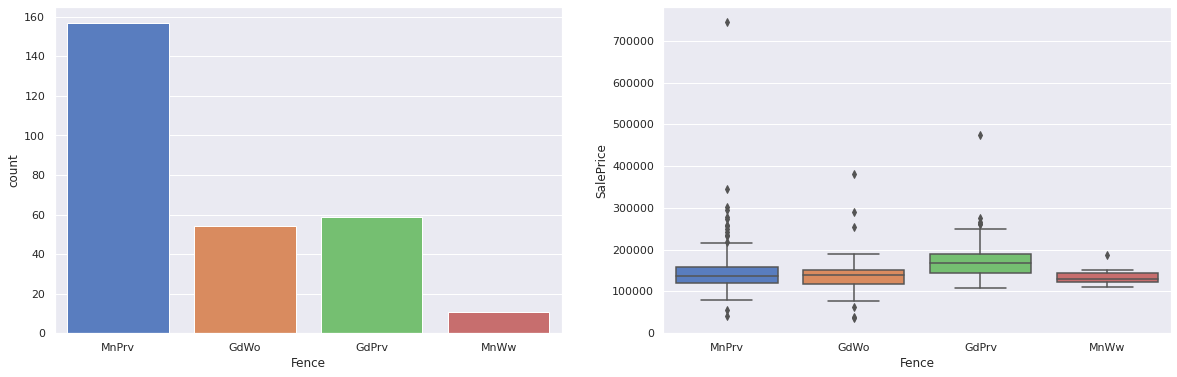

In [76]:
categorial_feature_overview('Fence')

# MiscFeature

Miscellaneous feature not covered in other categories

* Elev - Elevator
* Gar2 - 2nd Garage (if not described in garage section)
* Othr - Other
* Shed - Shed (over 100 SF)
* TenC - Tennis Court
* NA - None

MiscFeature has 96.30136986301369 % of null values


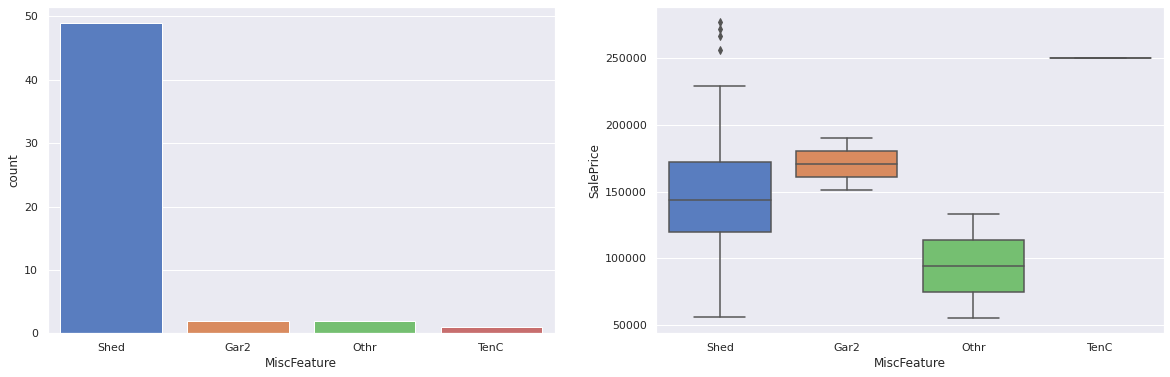

In [77]:
categorial_feature_overview('MiscFeature')

# MiscVal

$Value of miscellaneous feature

MiscVal has 0.0 % of null values


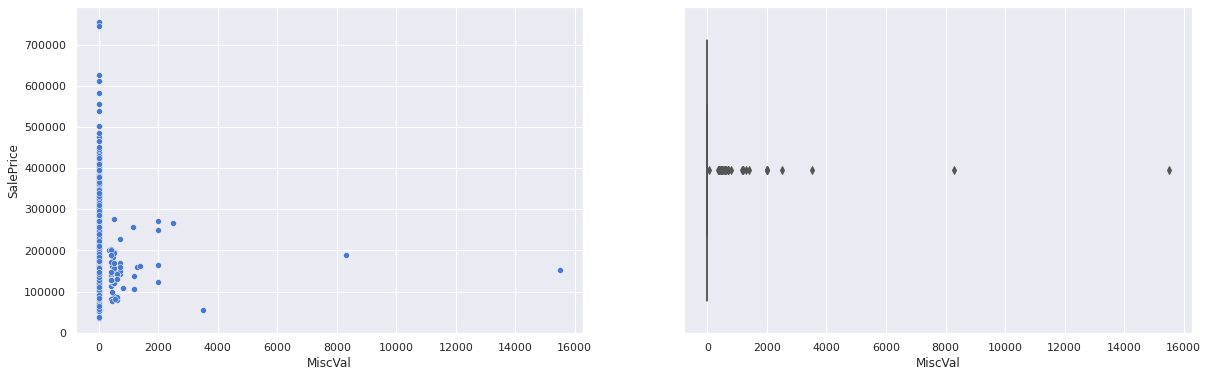

In [78]:
numerical_feature_overview('MiscVal')

# MoSold

Month Sold (MM)

MoSold has 0.0 % of null values


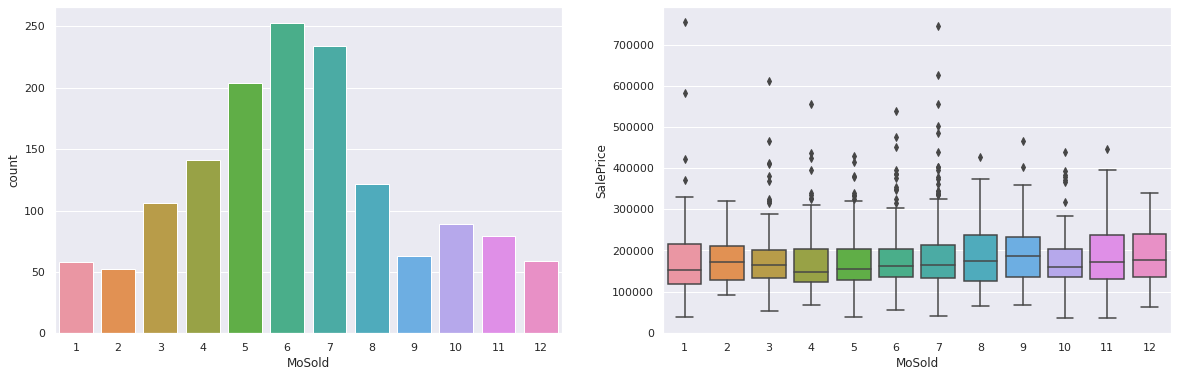

In [79]:
categorial_feature_overview('MoSold')

# YrSold

Year Sold (YYYY)

YrSold has 0.0 % of null values


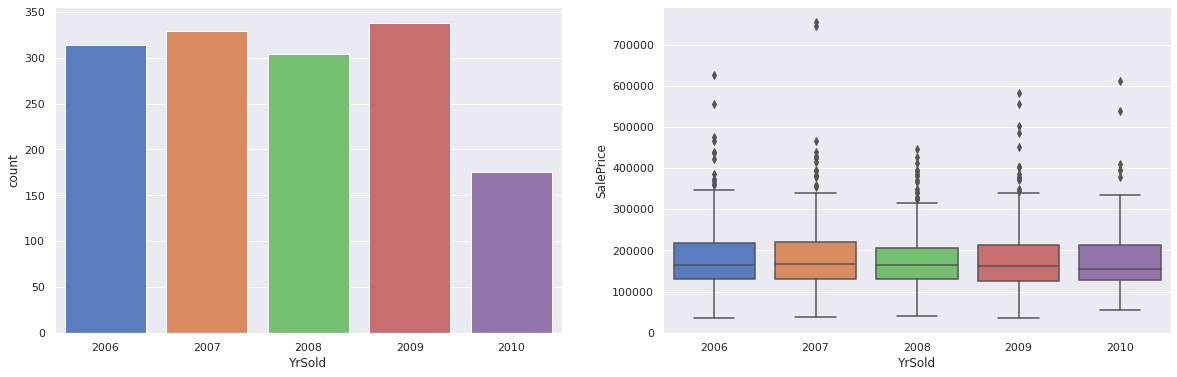

In [80]:
categorial_feature_overview('YrSold')

# SaleType

Type of sale

* WD - Warranty Deed - Conventional
* CWD - Warranty Deed - Cash
* VWD - Warranty Deed - VA Loan
* New - Home just constructed and sold
* COD - Court Officer Deed/Estate
* Con - Contract 15% Down payment regular terms
* ConLw - Contract Low Down payment and low interest
* ConLI - Contract Low Interest
* ConLD - Contract Low Down
* Oth - Other

SaleType has 0.0 % of null values


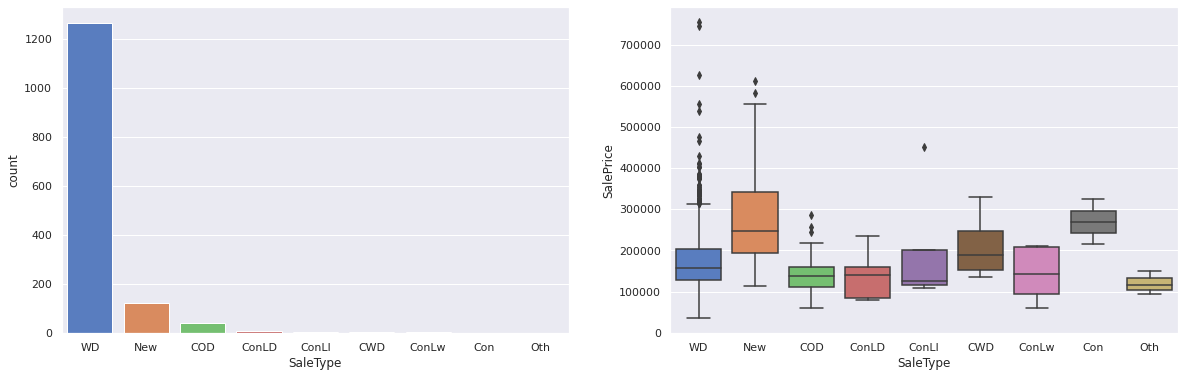

In [81]:
categorial_feature_overview('SaleType')

# SaleCondition

Condition of sale

* Normal - Normal Sale
* Abnorml - Abnormal Sale -  trade, foreclosure, short sale
* AdjLand - Adjoining Land Purchase
* Alloca - Allocation - two linked properties with separate deeds, typically condo with a garage unit
* Family - Sale between family members
* Partial - Home was not completed when last assessed (associated with New Homes)

SaleCondition has 0.0 % of null values


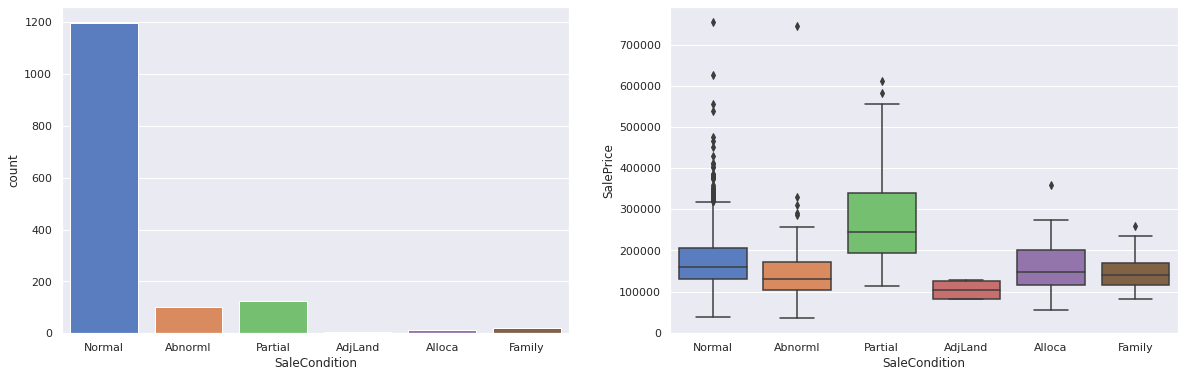

In [82]:
categorial_feature_overview('SaleCondition')

In [83]:
hf = h2o.H2OFrame(df)

x = list(df.columns.difference(['Id', 'SalePrice']).values)

y = "SalePrice"

aml = H2OAutoML(max_models=100, seed=1)
aml.train(x=x, y=y, training_frame=hf)


lb = aml.leaderboard
lb.head(rows=lb.nrows)  

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%


model_id,mean_residual_deviance,rmse,mse,mae,rmsle
StackedEnsemble_BestOfFamily_5_AutoML_1_20211010_81409,7.10339e+08,26652.2,7.10339e+08,15125.9,0.125101
GBM_grid_1_AutoML_1_20211010_81409_model_6,7.22258e+08,26874.9,7.22258e+08,15702.2,0.130218
StackedEnsemble_BestOfFamily_4_AutoML_1_20211010_81409,7.22286e+08,26875.4,7.22286e+08,15291.5,0.125714
GBM_grid_1_AutoML_1_20211010_81409_model_15,7.29989e+08,27018.3,7.29989e+08,15992.7,0.132384
GBM_grid_1_AutoML_1_20211010_81409_model_9,7.30624e+08,27030.1,7.30624e+08,15487.1,0.130766
GBM_grid_1_AutoML_1_20211010_81409_model_17,7.35256e+08,27115.6,7.35256e+08,15804.5,0.130329
GBM_grid_1_AutoML_1_20211010_81409_model_2,7.48879e+08,27365.7,7.48879e+08,16291.1,0.134309
GBM_grid_1_AutoML_1_20211010_81409_model_21,7.52122e+08,27424.8,7.52122e+08,15905,0.131115
GBM_grid_1_AutoML_1_20211010_81409_model_3,7.53196e+08,27444.4,7.53196e+08,15797.1,0.132538
GBM_grid_1_AutoML_1_20211010_81409_model_7,7.57648e+08,27525.4,7.57648e+08,15739.6,0.130984


In [84]:
df_test = pd.read_csv('../input/house-prices-advanced-regression-techniques/test.csv')

hf_test = h2o.H2OFrame(df_test)

x = list(df.columns.difference(['Id']).values)

preds = aml.predict(hf_test);

h2o.h2o.download_csv(preds, 'h20_output.csv')

df_SalePrice = pd.read_csv('./h20_output.csv')

output_df = pd.DataFrame({
    'Id': df_test['Id'],
    'SalePrice': df_SalePrice['predict']
})

output_df.to_csv('output.csv', index=False)

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%


/opt/conda/lib/python3.7/site-packages/h2o/job.py:83: UserWarning: Test/Validation dataset column 'MSZoning' has levels not trained on: ["nan"]
  warnings.warn(w)
/opt/conda/lib/python3.7/site-packages/h2o/job.py:83: UserWarning: Test/Validation dataset column 'Utilities' has levels not trained on: ["nan"]
  warnings.warn(w)
/opt/conda/lib/python3.7/site-packages/h2o/job.py:83: UserWarning: Test/Validation dataset column 'Exterior1st' has levels not trained on: ["nan"]
  warnings.warn(w)
/opt/conda/lib/python3.7/site-packages/h2o/job.py:83: UserWarning: Test/Validation dataset column 'Exterior2nd' has levels not trained on: ["nan"]
  warnings.warn(w)
/opt/conda/lib/python3.7/site-packages/h2o/job.py:83: UserWarning: Test/Validation dataset column 'KitchenQual' has levels not trained on: ["nan"]
  warnings.warn(w)
/opt/conda/lib/python3.7/site-packages/h2o/job.py:83: UserWarning: Test/Validation dataset column 'Functional' has levels not trained on: ["nan"]
  warnings.warn(w)
/opt/conda